In [1]:
!pip uninstall -y numpy pandas seaborn matplotlib
!pip install --no-cache-dir numpy==1.26.4 pandas==2.2.2 seaborn==0.13.2 matplotlib==3.8.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Successfully uninstalled seaborn-0.13.2
Found existing installation: matplotlib 3.8.4
Uninstalling matplotlib-3.8.4:
  Successfully uninstalled matplotlib-3.8.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 165.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 166.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 346.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 155.2 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavi

In [2]:
# ── Install dependencies (Kaggle T4 compatible) ──────────────────────────────
!pip install -q "numpy<2.0" transformers captum transformers-interpret \
    lime shap seaborn matplotlib scikit-learn torch scipy
print("✅ All packages ready")

✅ All packages ready


In [3]:
# ── Imports & Global Style ────────────────────────────────────────────────────
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import math, string, re, warnings, os
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
from transformers_interpret import QuestionAnsweringExplainer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import entropy as scipy_entropy
from captum.attr import (
    IntegratedGradients, InputXGradient, LayerIntegratedGradients,
    LayerGradientXActivation, LayerActivation
)
import shap
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Publication-quality style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.framealpha': 0.9,
    'savefig.bbox': 'tight',
})

PALETTE = sns.color_palette("tab10")
CMAP_DIV  = 'RdBu_r'
CMAP_SEQ  = 'viridis'
CMAP_HEAT = 'mako'

# ── Helper ─────────────────────────────────────────────────────────────────────
def save_or_show(fig, name):
    os.makedirs('xai_figures', exist_ok=True)
    fig.savefig(f'xai_figures/{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Imports done — style configured for publication-quality output")

✅ Imports done — style configured for publication-quality output


In [4]:
# ── Model & Tokeniser ─────────────────────────────────────────────────────────
MODEL_NAME = "deepset/roberta-large-squad2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForQuestionAnswering.from_pretrained(
    MODEL_NAME, output_attentions=True, output_hidden_states=True
)
model.eval()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(DEVICE)
print(f"Device: {DEVICE}")

# ── Context & Question ────────────────────────────────────────────────────────
context = (
    "Quantum optimization algorithms, such as the Quantum Approximate Optimization "
    "Algorithm (QAOA), leverage the principles of quantum mechanics to solve "
    "combinatorial optimization problems. By utilizing quantum superposition and "
    "entanglement, these hybrid quantum-classical algorithms aim to find the optimal "
    "solution significantly faster than classical brute-force methods."
)
question = "What principles do quantum optimization algorithms leverage to solve problems?"

# ── Tokenise ──────────────────────────────────────────────────────────────────
inputs = tokenizer(question, context, return_tensors="pt", truncation=True)
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
N_TOKENS = len(tokens)

# ── Baseline forward pass ────────────────────────────────────────────────────
with torch.no_grad():
    outputs = model(**inputs)

start_probs = torch.softmax(outputs.start_logits, dim=-1)[0].cpu().numpy()
end_probs   = torch.softmax(outputs.end_logits,   dim=-1)[0].cpu().numpy()
ORIG_S = int(np.argmax(start_probs))
ORIG_E = int(np.argmax(end_probs))

predicted_answer = tokenizer.convert_tokens_to_string(
    [t.replace('Ġ', ' ') for t in tokens[ORIG_S:ORIG_E+1]]
).strip()

print(f"\n❓ Question  : {question}")
print(f"📚 Context   : {context}")
print(f"\n✅ Predicted Answer: '{predicted_answer}'")
print(f"   Start idx={ORIG_S}, End idx={ORIG_E}")
print(f"   Start conf={start_probs[ORIG_S]:.4f}, End conf={end_probs[ORIG_E]:.4f}")

config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-large-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda

❓ Question  : What principles do quantum optimization algorithms leverage to solve problems?
📚 Context   : Quantum optimization algorithms, such as the Quantum Approximate Optimization Algorithm (QAOA), leverage the principles of quantum mechanics to solve combinatorial optimization problems. By utilizing quantum superposition and entanglement, these hybrid quantum-classical algorithms aim to find the optimal solution significantly faster than classical brute-force methods.

✅ Predicted Answer: 'quantum mechanics'
   Start idx=39, End idx=40
   Start conf=0.9432, End conf=0.9970


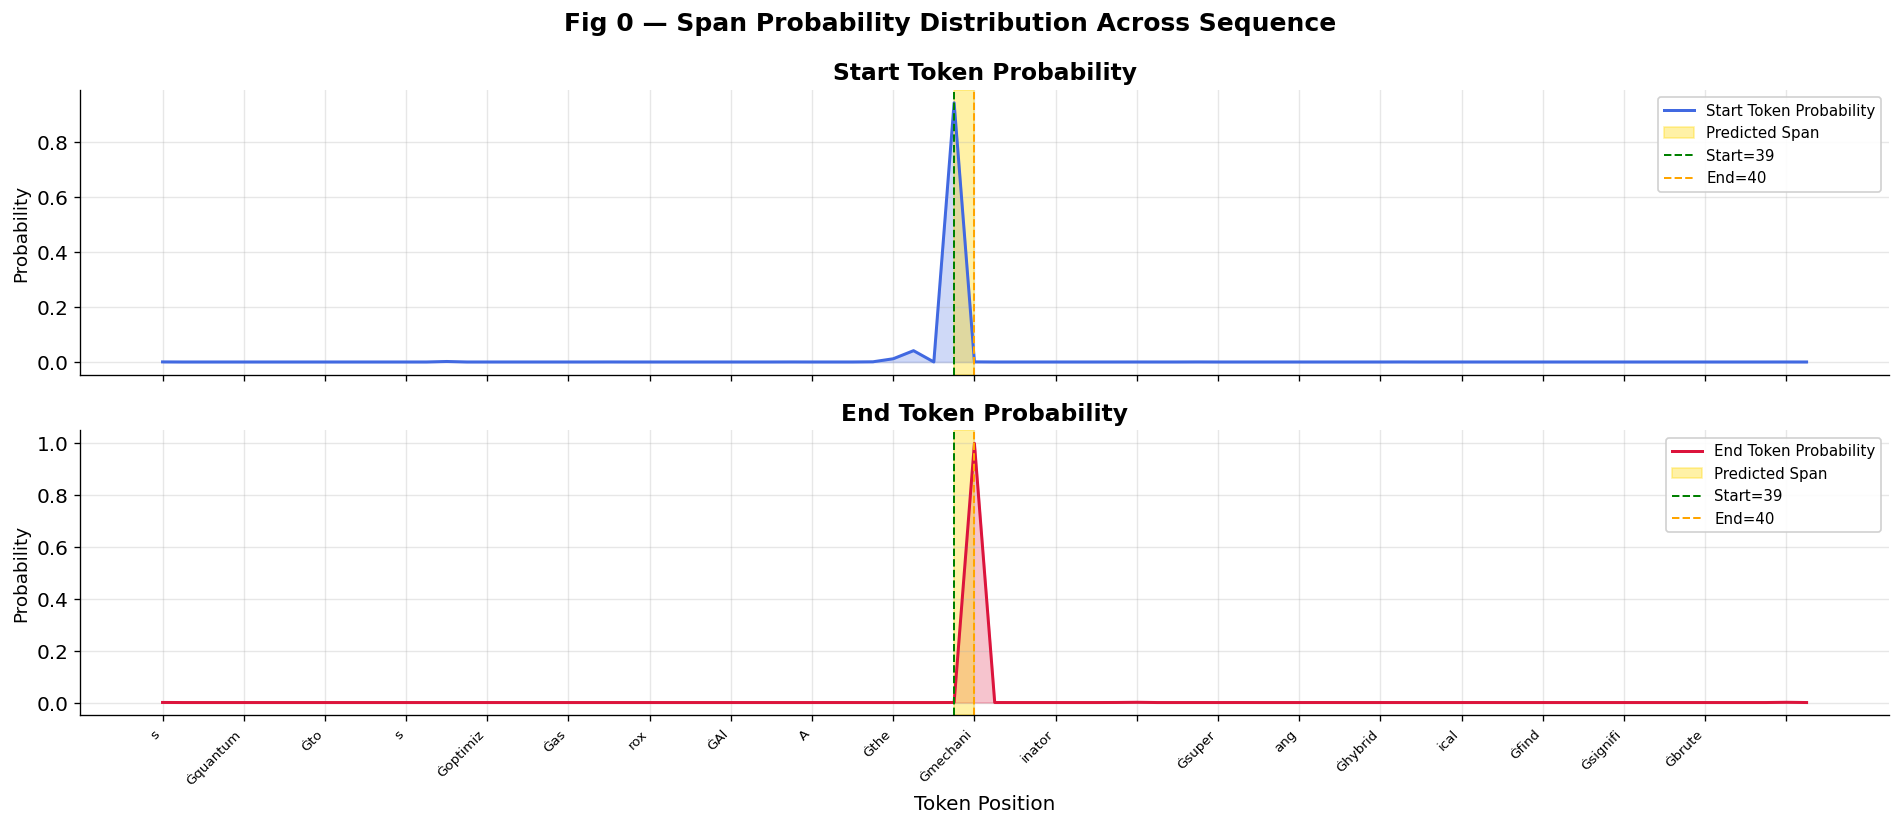

In [5]:
# ── Fig 0: Token span probability overview ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

clean_toks = [re.sub(r'[^a-zA-Z0-9Ġ]', '', t) for t in tokens]
x = np.arange(N_TOKENS)

for ax, probs, label, color in zip(
    axes,
    [start_probs, end_probs],
    ['Start Token Probability', 'End Token Probability'],
    ['royalblue', 'crimson']
):
    ax.fill_between(x, probs, alpha=0.25, color=color)
    ax.plot(x, probs, color=color, linewidth=1.8, label=label)
    ax.axvspan(ORIG_S, ORIG_E, color='gold', alpha=0.35, label='Predicted Span')
    ax.axvline(ORIG_S, color='green', linestyle='--', linewidth=1.2, label=f'Start={ORIG_S}')
    ax.axvline(ORIG_E, color='orange', linestyle='--', linewidth=1.2, label=f'End={ORIG_E}')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(label)
    ax.legend(loc='upper right', fontsize=9)

# tick labels every 4 tokens
step = max(1, N_TOKENS // 20)
axes[1].set_xticks(x[::step])
axes[1].set_xticklabels(
    [clean_toks[i][:8] for i in range(0, N_TOKENS, step)],
    rotation=45, ha='right', fontsize=8
)
axes[1].set_xlabel('Token Position')

fig.suptitle('Fig 0 — Span Probability Distribution Across Sequence', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig00_span_probs')

In [6]:
!pip install captum


In [7]:
# ── Entropy helpers ───────────────────────────────────────────────────────────
def shannon_entropy_bits(probs):
    """Entropy in bits; ignores zero-probability entries."""
    p = np.clip(probs, 1e-12, None)
    return float(-np.sum(p * np.log2(p)))

H_start = shannon_entropy_bits(start_probs)
H_end   = shannon_entropy_bits(end_probs)
H_avg   = (H_start + H_end) / 2
max_H   = np.log2(N_TOKENS)  # maximum possible entropy
norm_H  = H_avg / max_H

print("=" * 55)
print(f"  Start entropy  : {H_start:.4f} bits")
print(f"  End   entropy  : {H_end:.4f} bits")
print(f"  Average entropy: {H_avg:.4f} bits")
print(f"  Max possible   : {max_H:.4f} bits")
print(f"  Normalised H   : {norm_H:.4f}  ({norm_H*100:.1f}% of max)")
print("  Diagnosis:", "HIGH CONFIDENCE" if H_avg < 1.5 else "UNCERTAIN")
print("=" * 55)

  Start entropy  : 0.3858 bits
  End   entropy  : 0.0393 bits
  Average entropy: 0.2125 bits
  Max possible   : 6.3576 bits
  Normalised H   : 0.0334  (3.3% of max)
  Diagnosis: HIGH CONFIDENCE


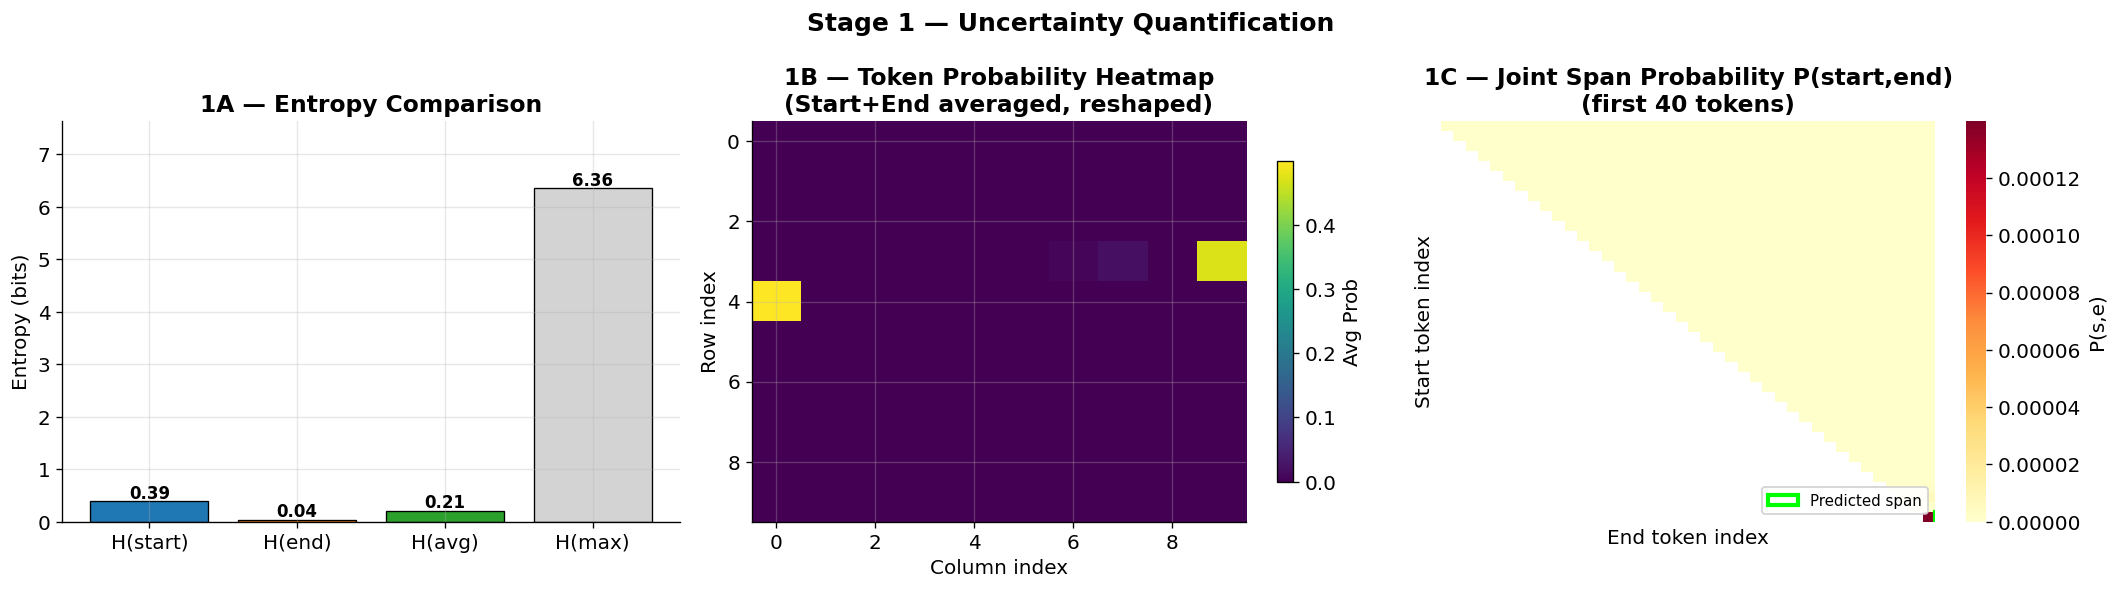

In [8]:
# ── Fig 1A: Entropy gauge ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: bar chart of H_start / H_end / H_avg vs max
ax = axes[0]
vals   = [H_start, H_end, H_avg, max_H]
labels = ['H(start)', 'H(end)', 'H(avg)', 'H(max)']
colors = [PALETTE[0], PALETTE[1], PALETTE[2], 'lightgray']
bars = ax.bar(labels, vals, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Entropy (bits)')
ax.set_title('1A — Entropy Comparison')
ax.set_ylim(0, max_H * 1.2)

# Middle: token-level entropy heatmap (each token's probability reshaped)
ax = axes[1]
combined = (start_probs + end_probs) / 2
# reshape to square-ish matrix for heatmap readability
side = int(np.ceil(np.sqrt(N_TOKENS)))
padded = np.zeros(side * side)
padded[:N_TOKENS] = combined
mat = padded.reshape(side, side)
im = ax.imshow(mat, cmap=CMAP_SEQ, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Avg Prob')
ax.set_title('1B — Token Probability Heatmap\n(Start+End averaged, reshaped)')
ax.set_xlabel('Column index'); ax.set_ylabel('Row index')

# Right: joint span probability matrix (top-left corner)
ax = axes[2]
LIMIT = min(40, N_TOKENS)
joint = np.outer(start_probs[:LIMIT], end_probs[:LIMIT])
# mask lower triangle (end < start is invalid)
mask = np.tril(np.ones_like(joint, dtype=bool), k=-1)
joint_masked = np.where(mask, np.nan, joint)
sns.heatmap(joint_masked, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'P(s,e)'},
            xticklabels=False, yticklabels=False)
ax.set_title('1C — Joint Span Probability P(start,end)\n(first 40 tokens)')
ax.set_xlabel('End token index'); ax.set_ylabel('Start token index')
ax.add_patch(plt.Rectangle((ORIG_E, ORIG_S), 1, 1, fill=False,
                             edgecolor='lime', lw=2.5, label='Predicted span'))
ax.legend(loc='lower right', fontsize=9)

fig.suptitle('Stage 1 — Uncertainty Quantification', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig01_uncertainty')

In [9]:
# ── Captum forward wrappers ───────────────────────────────────────────────────
def forward_start(input_ids, attention_mask, token_type_ids=None):
    """Return start logit for the predicted start position."""
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    return out.start_logits[:, ORIG_S]

def forward_end(input_ids, attention_mask, token_type_ids=None):
    """Return end logit for the predicted end position."""
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    return out.end_logits[:, ORIG_E]

input_ids      = inputs['input_ids']
attention_mask = inputs['attention_mask']
baseline_ids   = torch.zeros_like(input_ids)   # zero-embedding baseline

# ── Layer IG on embedding layer ───────────────────────────────────────────────
embed_layer = model.roberta.embeddings.word_embeddings

lig_start = LayerIntegratedGradients(forward_start, embed_layer)
lig_end   = LayerIntegratedGradients(forward_end,   embed_layer)

attr_start, delta_s = lig_start.attribute(
    input_ids, baselines=baseline_ids,
    additional_forward_args=(attention_mask,),
    n_steps=50, return_convergence_delta=True
)
attr_end, delta_e = lig_end.attribute(
    input_ids, baselines=baseline_ids,
    additional_forward_args=(attention_mask,),
    n_steps=50, return_convergence_delta=True
)

# Summarise across embedding dimension → per-token scalar
ig_start_scores = attr_start[0].sum(dim=-1).detach().cpu().numpy()
ig_end_scores   = attr_end[0].sum(dim=-1).detach().cpu().numpy()
ig_avg_scores   = (np.abs(ig_start_scores) + np.abs(ig_end_scores)) / 2

print(f"Convergence delta (start): {delta_s.item():.4f}")
print(f"Convergence delta (end)  : {delta_e.item():.4f}")
print("(Values close to 0 → good approximation)")

Convergence delta (start): 157.1859
Convergence delta (end)  : -63.5333
(Values close to 0 → good approximation)


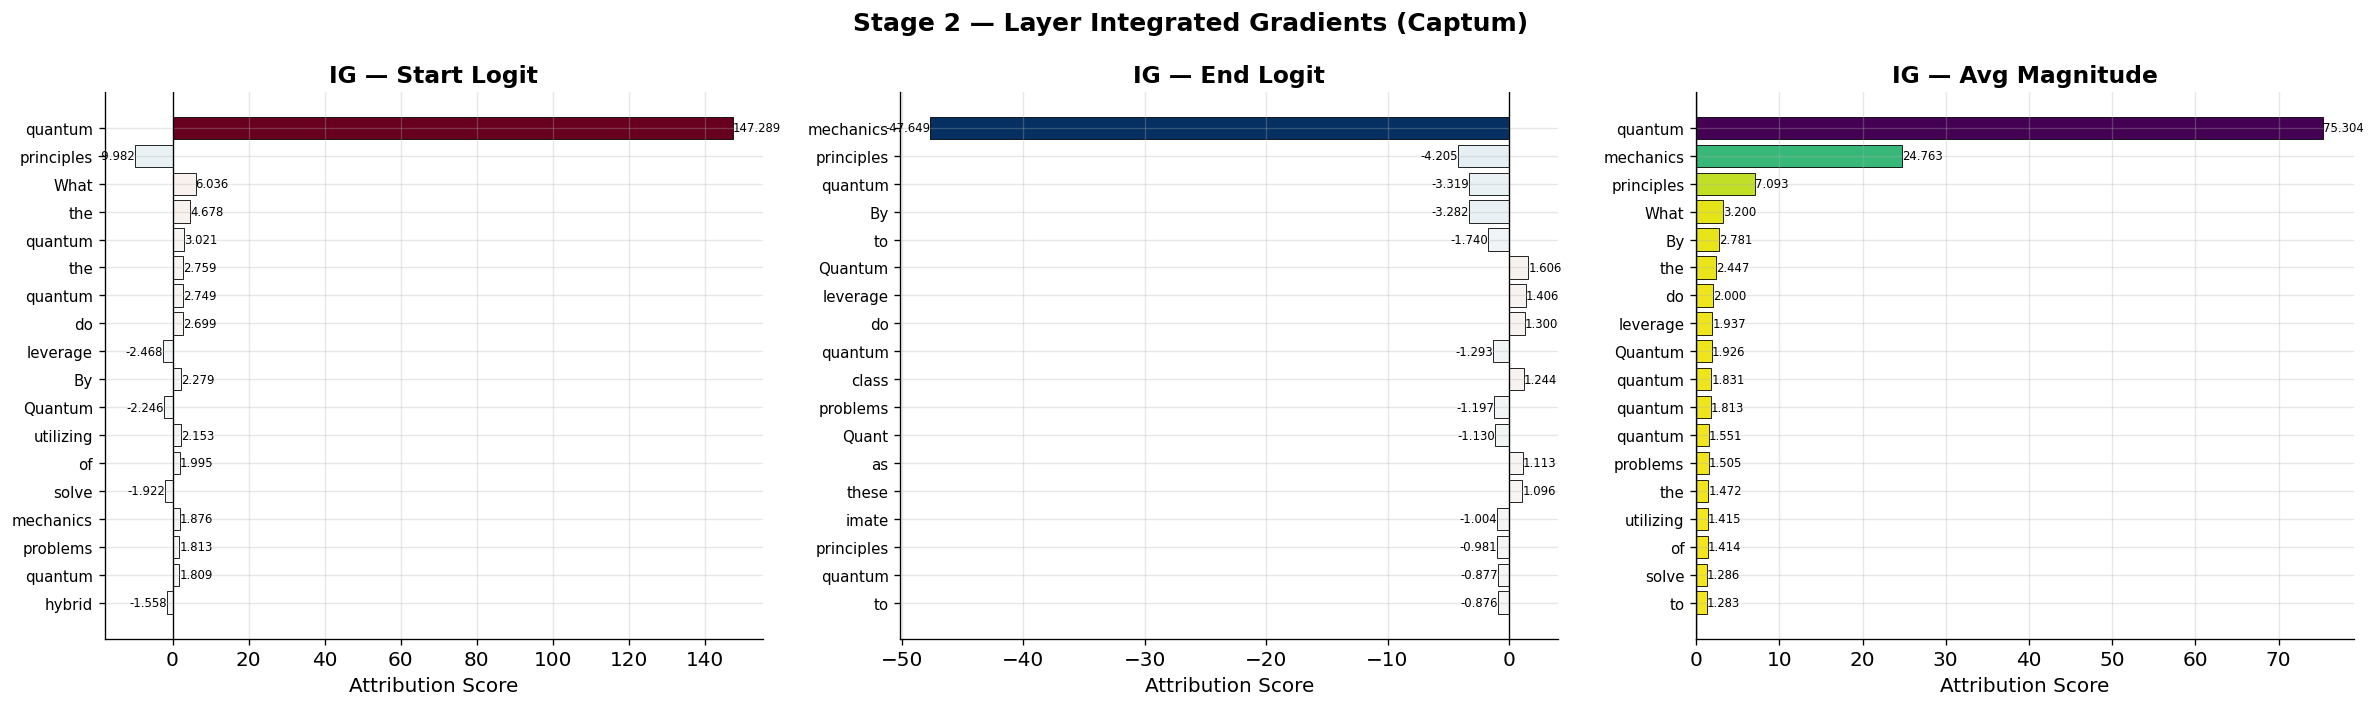

In [10]:
# ── Helpers: filter special tokens ───────────────────────────────────────────
SPECIAL = {tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token}

def filter_tokens_scores(scores, keep_top=20):
    """Return (labels, values) for top tokens, excluding specials."""
    pairs = [
        (re.sub(r'[^a-zA-Z0-9]', '', t.replace('Ġ', '')), s)
        for t, s in zip(tokens, scores)
        if t not in SPECIAL and len(re.sub(r'[^a-zA-Z0-9]', '', t.replace('Ġ', ''))) > 1
    ]
    pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    labels = [p[0] for p in pairs[:keep_top]]
    values = [p[1] for p in pairs[:keep_top]]
    return labels, values

# ── Fig 2: Integrated Gradients ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, scores, title, cmap_key in zip(
    axes,
    [ig_start_scores, ig_end_scores, ig_avg_scores],
    ['IG — Start Logit', 'IG — End Logit', 'IG — Avg Magnitude'],
    [True, True, False]
):
    labs, vals = filter_tokens_scores(scores, keep_top=18)
    # Diverging colours for signed; sequential for magnitude
    norm = plt.Normalize(vmin=-max(abs(v) for v in vals), vmax=max(abs(v) for v in vals))
    cmap = cm.RdBu_r if cmap_key else cm.viridis_r
    bar_colors = [cmap(norm(v)) if cmap_key else cmap(abs(v)/max(abs(v) for v in vals))
                  for v in vals]
    bars = ax.barh(range(len(labs)), vals, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(labs)))
    ax.set_yticklabels(labs, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Attribution Score')
    ax.set_title(title)
    # Annotate bar values
    for bar, val in zip(bars, vals):
        ax.text(val + (0.0005 if val >= 0 else -0.0005),
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7)

fig.suptitle('Stage 2 — Layer Integrated Gradients (Captum)', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig02_integrated_gradients')

In [11]:
# ── Grad × Input ──────────────────────────────────────────────────────────────
gxi_start = LayerGradientXActivation(forward_start, embed_layer)
gxi_end   = LayerGradientXActivation(forward_end,   embed_layer)

gxi_s = gxi_start.attribute(input_ids, additional_forward_args=(attention_mask,))
gxi_e = gxi_end.attribute(  input_ids, additional_forward_args=(attention_mask,))

gxi_s_scores = gxi_s[0].sum(dim=-1).detach().cpu().numpy()
gxi_e_scores = gxi_e[0].sum(dim=-1).detach().cpu().numpy()
gxi_avg      = (np.abs(gxi_s_scores) + np.abs(gxi_e_scores)) / 2

print("Grad×Input scores computed ✅")

Grad×Input scores computed ✅


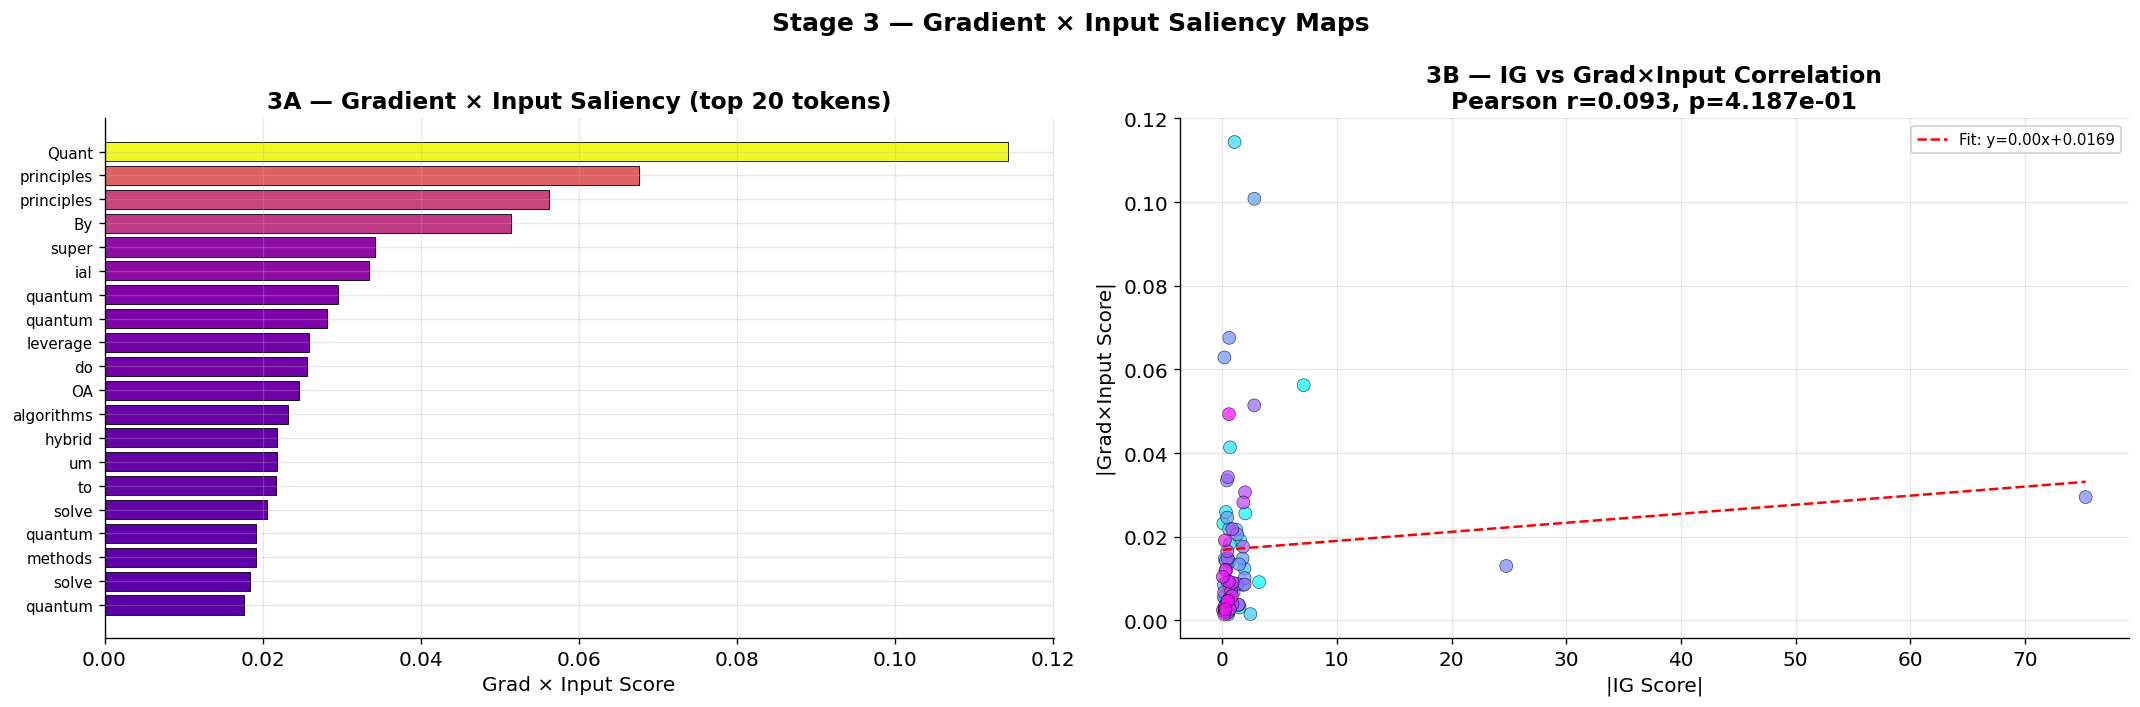

In [12]:
# ── Fig 3: Grad×Input + comparison with IG ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Grad×Input bar
labs, vals = filter_tokens_scores(gxi_avg, keep_top=20)
norm_vals = np.array(vals) / (max(vals) + 1e-9)
bar_colors = cm.plasma(norm_vals)
axes[0].barh(range(len(labs)), vals, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(len(labs))); axes[0].set_yticklabels(labs, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Grad × Input Score')
axes[0].set_title('3A — Gradient × Input Saliency (top 20 tokens)')

# Right: rank correlation scatter between IG and GxI
ax = axes[1]
# build aligned vectors (only non-special tokens)
pairs = [
    (abs(ig_avg_scores[i]), abs(gxi_avg[i]))
    for i, t in enumerate(tokens)
    if t not in SPECIAL
]
ig_v, gxi_v = zip(*pairs)
ax.scatter(ig_v, gxi_v, alpha=0.7, s=60, c=range(len(ig_v)), cmap='cool', edgecolors='k', linewidth=0.4)
# fit line
m, b = np.polyfit(ig_v, gxi_v, 1)
x_line = np.linspace(min(ig_v), max(ig_v), 100)
ax.plot(x_line, m*x_line + b, 'r--', linewidth=1.5, label=f'Fit: y={m:.2f}x+{b:.4f}')
from scipy.stats import pearsonr
r, p = pearsonr(ig_v, gxi_v)
ax.set_title(f'3B — IG vs Grad×Input Correlation\nPearson r={r:.3f}, p={p:.3e}')
ax.set_xlabel('|IG Score|'); ax.set_ylabel('|Grad×Input Score|')
ax.legend(fontsize=9)

fig.suptitle('Stage 3 — Gradient × Input Saliency Maps', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig03_gradxinput')

In [13]:
# ── Stack all attention layers ────────────────────────────────────────────────
# outputs.attentions: tuple of (batch, heads, seq, seq) per layer
all_attn = torch.stack(outputs.attentions, dim=0)  # (layers, 1, heads, seq, seq)
all_attn = all_attn[:, 0, :, :, :].detach().cpu()  # (layers, heads, seq, seq)
N_LAYERS, N_HEADS, SEQ, _ = all_attn.shape

# ── Attention rollout ─────────────────────────────────────────────────────────
def attention_rollout(attn_tensor):
    """
    attn_tensor: (layers, heads, seq, seq)
    Returns rollout matrix (seq, seq).
    """
    rollout = torch.eye(SEQ)
    for layer_attn in attn_tensor:
        avg_head = layer_attn.mean(dim=0)           # (seq, seq)
        # add residual connection: 0.5 * attn + 0.5 * I
        attn_res = 0.5 * avg_head + 0.5 * torch.eye(SEQ)
        attn_res = attn_res / attn_res.sum(dim=-1, keepdim=True)
        rollout = torch.matmul(attn_res, rollout)
    return rollout.numpy()

rollout_mat = attention_rollout(all_attn)

# ── Head importance: mean attention entropy per head ─────────────────────────
# Lower entropy → more focused head → more "important"
head_entropies = np.zeros((N_LAYERS, N_HEADS))
for l in range(N_LAYERS):
    for h in range(N_HEADS):
        p = all_attn[l, h].numpy()  # (seq, seq)
        row_ent = -np.sum(p * np.log2(np.clip(p, 1e-12, None)), axis=-1)
        head_entropies[l, h] = row_ent.mean()

print(f"Attention rollout shape: {rollout_mat.shape}")
print(f"Head entropies shape:    {head_entropies.shape}")

Attention rollout shape: (82, 82)
Head entropies shape:    (24, 16)


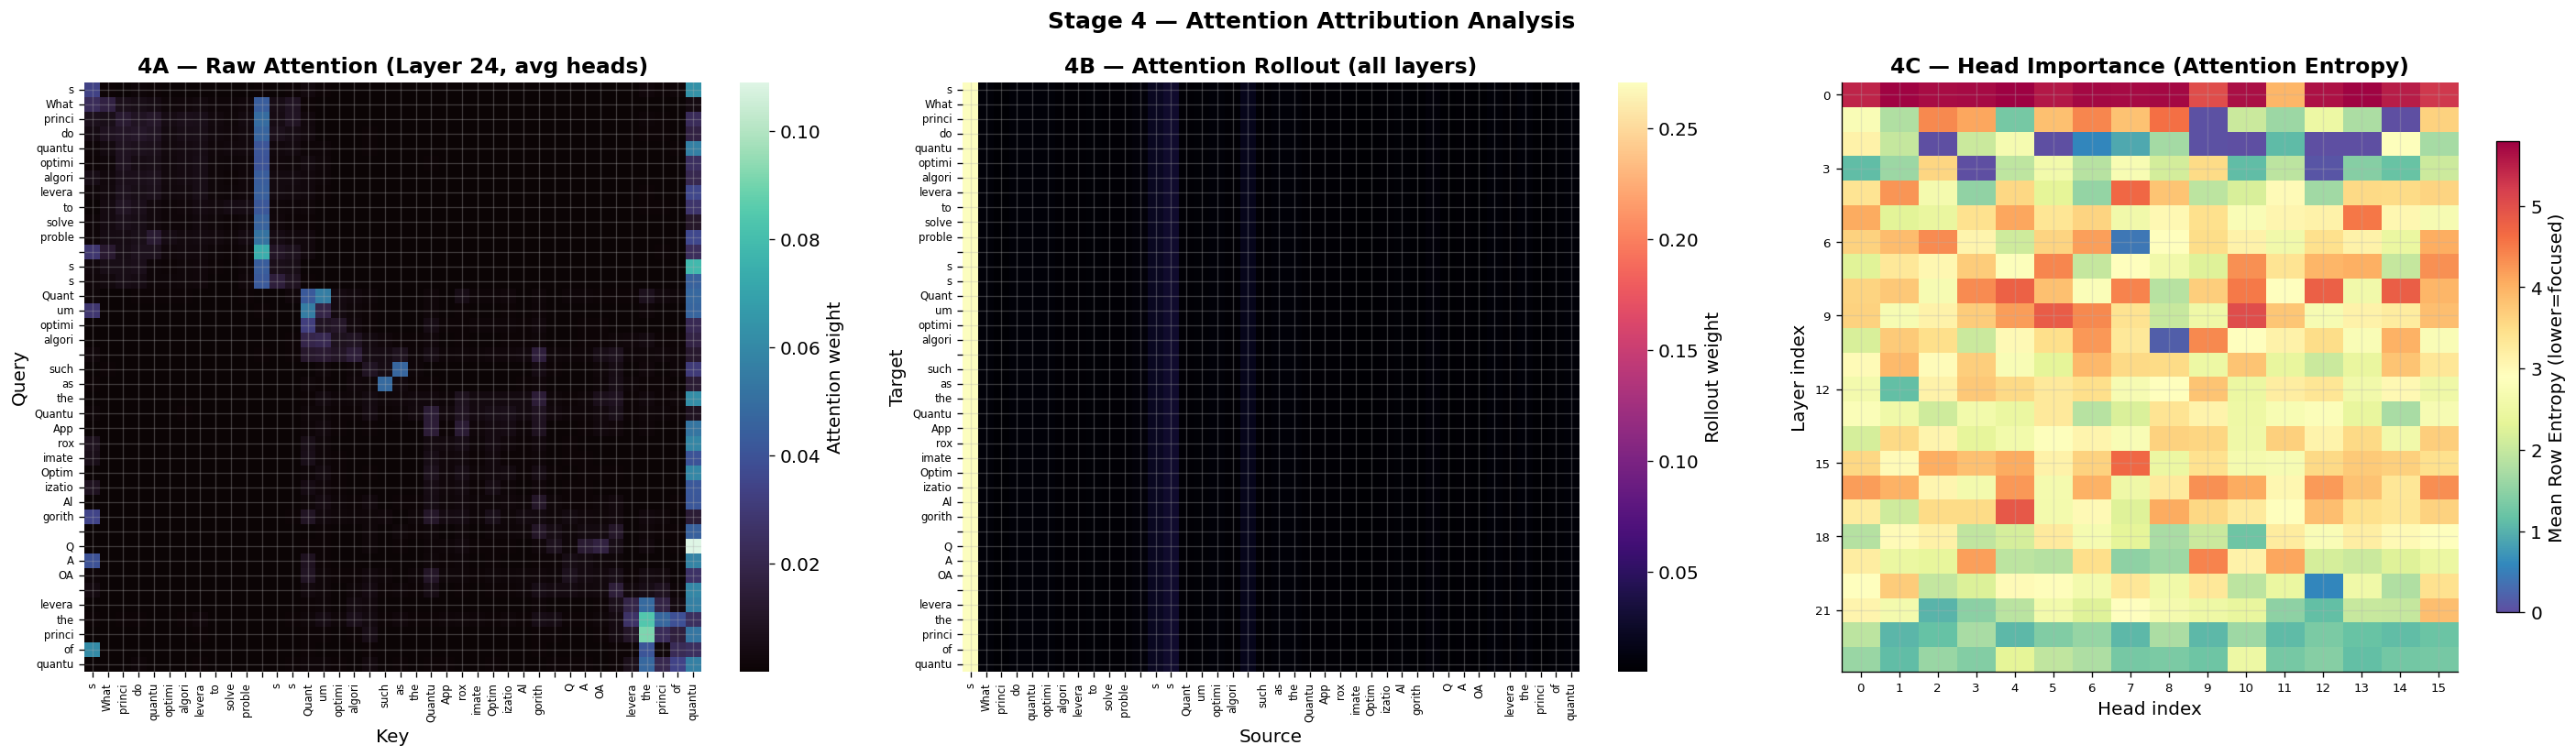

In [14]:
# ── Fig 4A: Raw last-layer attention heatmap ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

LIMIT = min(40, SEQ)
clean_axis = [re.sub(r'[^a-zA-Z0-9]', '', t)[:6] for t in tokens[:LIMIT]]

# 4A: Last layer avg-head attention
last_attn_avg = all_attn[-1].mean(dim=0).numpy()[:LIMIT, :LIMIT]
sns.heatmap(last_attn_avg, ax=axes[0],
            xticklabels=clean_axis, yticklabels=clean_axis,
            cmap=CMAP_HEAT, cbar_kws={'label': 'Attention weight'})
axes[0].set_title('4A — Raw Attention (Layer 24, avg heads)')
axes[0].set_xlabel('Key'); axes[0].set_ylabel('Query')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# 4B: Attention rollout heatmap
sns.heatmap(rollout_mat[:LIMIT, :LIMIT], ax=axes[1],
            xticklabels=clean_axis, yticklabels=clean_axis,
            cmap='magma', cbar_kws={'label': 'Rollout weight'})
axes[1].set_title('4B — Attention Rollout (all layers)')
axes[1].set_xlabel('Source'); axes[1].set_ylabel('Target')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

# 4C: Head importance heatmap (entropy)
im = axes[2].imshow(head_entropies, aspect='auto', cmap='Spectral_r')
plt.colorbar(im, ax=axes[2], shrink=0.8, label='Mean Row Entropy (lower=focused)')
axes[2].set_xlabel('Head index'); axes[2].set_ylabel('Layer index')
axes[2].set_title('4C — Head Importance (Attention Entropy)')
axes[2].set_xticks(range(N_HEADS)); axes[2].set_xticklabels(range(N_HEADS), fontsize=8)
axes[2].set_yticks(range(0, N_LAYERS, 3)); axes[2].set_yticklabels(range(0, N_LAYERS, 3), fontsize=8)

fig.suptitle('Stage 4 — Attention Attribution Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig04_attention')

In [15]:
# ── LIME wrapper ──────────────────────────────────────────────────────────────
context_words = context.split()
N_CONTEXT_WORDS = len(context_words)

def qa_predict_proba(texts):
    """
    LIME calls this with a list of perturbed context strings.
    Returns (n_samples, 2) array: [P(not-answer), P(answer-span)].
    """
    results = []
    for text in texts:
        enc = tokenizer(question, text, return_tensors='pt',
                        truncation=True, max_length=512)
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        s_p = torch.softmax(out.start_logits, dim=-1)[0].cpu().numpy()
        e_p = torch.softmax(out.end_logits,   dim=-1)[0].cpu().numpy()
        # Use the top-1 joint prob as the "positive" score
        score = float(s_p.max() * e_p.max())
        score = min(max(score, 0.0), 1.0)
        results.append([1 - score, score])
    return np.array(results)

lime_explainer = LimeTextExplainer(class_names=['no-answer', 'answer'],
                                    random_state=SEED)
lime_exp = lime_explainer.explain_instance(
    context,
    qa_predict_proba,
    num_features=15,
    num_samples=200,   # keep low for speed; increase to 500 for accuracy
    labels=(1,)
)

lime_words, lime_scores = zip(*sorted(
    lime_exp.as_list(label=1), key=lambda x: abs(x[1]), reverse=True
))
print("LIME top tokens:", lime_words[:10])

LIME top tokens: ('mechanics', 'problems', 'hybrid', 'Approximate', 'combinatorial', 'of', 'and', 'principles', 'quantum', 'force')


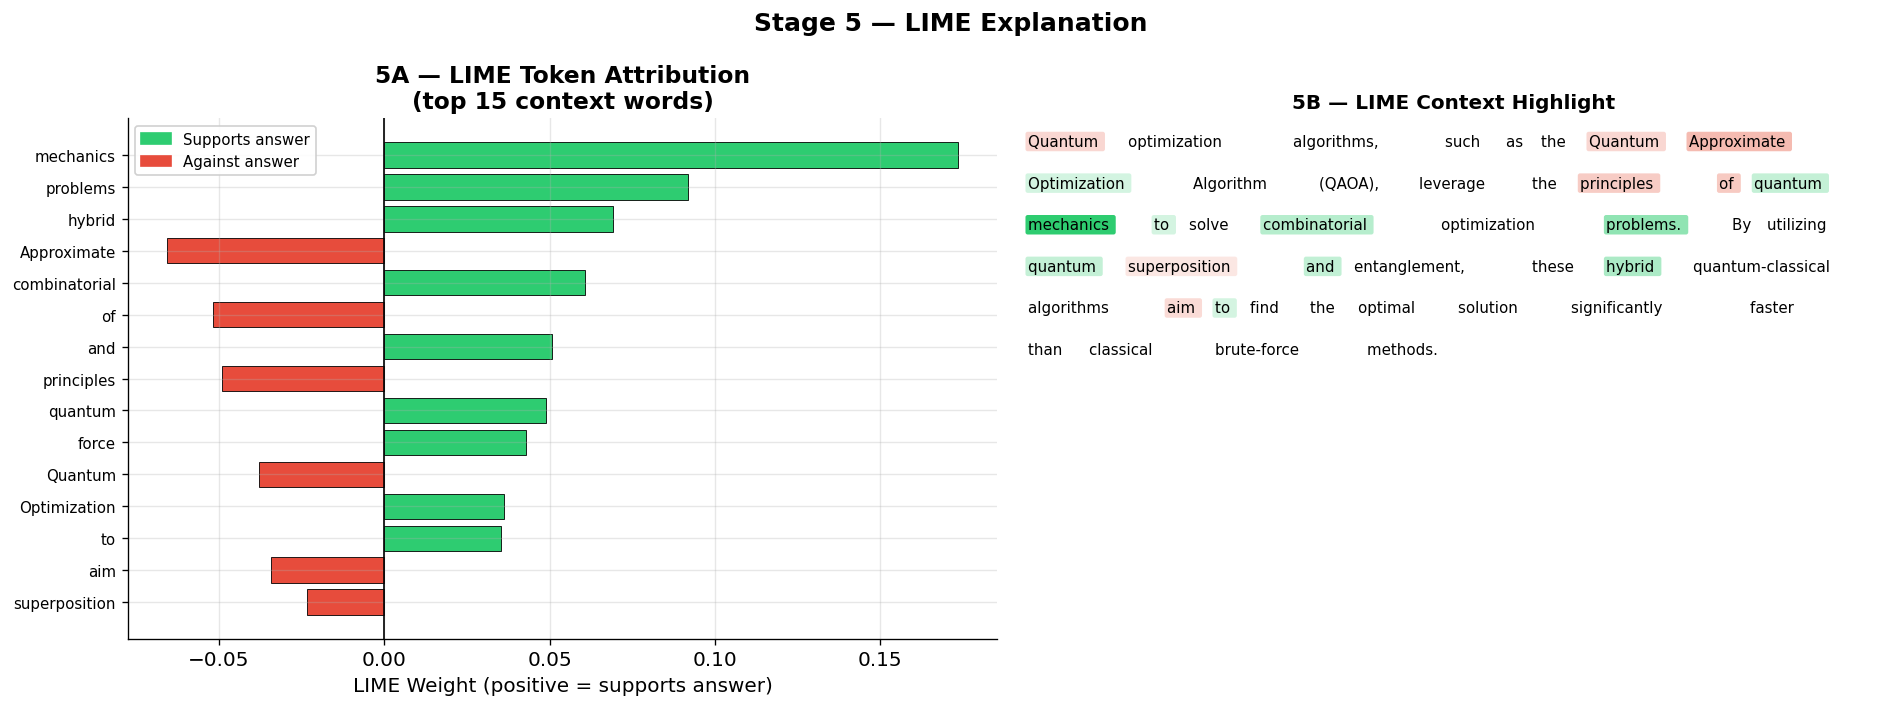

In [16]:
# ── Fig 5: LIME ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: horizontal bar
ax = axes[0]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in lime_scores]
bars = ax.barh(range(len(lime_words)), lime_scores, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(lime_words))); ax.set_yticklabels(lime_words, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('LIME Weight (positive = supports answer)')
ax.set_title('5A — LIME Token Attribution\n(top 15 context words)')
pos_patch = mpatches.Patch(color='#2ecc71', label='Supports answer')
neg_patch = mpatches.Patch(color='#e74c3c', label='Against answer')
ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

# Right: annotated context string
ax = axes[1]
ax.axis('off')
lime_dict = dict(lime_exp.as_list(label=1))
max_abs = max(abs(v) for v in lime_dict.values()) + 1e-9
words_ctx = context.split()
x_pos, y_pos = 0.01, 0.97
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
for word in words_ctx:
    clean = re.sub(r'[^a-zA-Z0-9]', '', word)
    score = lime_dict.get(clean, lime_dict.get(word, 0))
    intensity = abs(score) / max_abs
    fc = (0.18, 0.80, 0.44, intensity) if score > 0 else (0.90, 0.30, 0.20, intensity)
    t = ax.text(x_pos, y_pos, word + ' ', ha='left', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.15', facecolor=fc, edgecolor='none'))
    x_pos += len(word) * 0.015 + 0.01
    if x_pos > 0.90:
        x_pos = 0.01; y_pos -= 0.08
ax.set_title('5B — LIME Context Highlight', fontsize=12, fontweight='bold')

fig.suptitle('Stage 5 — LIME Explanation', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig05_lime')

In [17]:
# ── KernelSHAP on token-mask space ────────────────────────────────────────────
def masked_qa_score(mask_matrix):
    """
    mask_matrix: (n_samples, n_context_words) — binary mask.
    Returns (n_samples,) scores.
    """
    scores = []
    for mask in mask_matrix:
        words = [
            w if mask[i] == 1 else tokenizer.mask_token
            for i, w in enumerate(context_words)
        ]
        ctx_masked = ' '.join(words)
        enc = tokenizer(question, ctx_masked, return_tensors='pt',
                        truncation=True, max_length=512)
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        s_p = torch.softmax(out.start_logits, dim=-1)[0].cpu().numpy()
        e_p = torch.softmax(out.end_logits,   dim=-1)[0].cpu().numpy()
        scores.append(float(s_p.max() * e_p.max()))
    return np.array(scores)

background = np.ones((1, N_CONTEXT_WORDS))   # all tokens present = baseline
shap_explainer = shap.KernelExplainer(masked_qa_score, background)

# Single instance: all-ones (the actual context)
instance = np.ones((1, N_CONTEXT_WORDS))
shap_vals = shap_explainer.shap_values(instance, nsamples=100, silent=True)
shap_vals = shap_vals[0]  # shape (N_CONTEXT_WORDS,)
print(f"SHAP values shape: {shap_vals.shape}")

SHAP values shape: (44,)


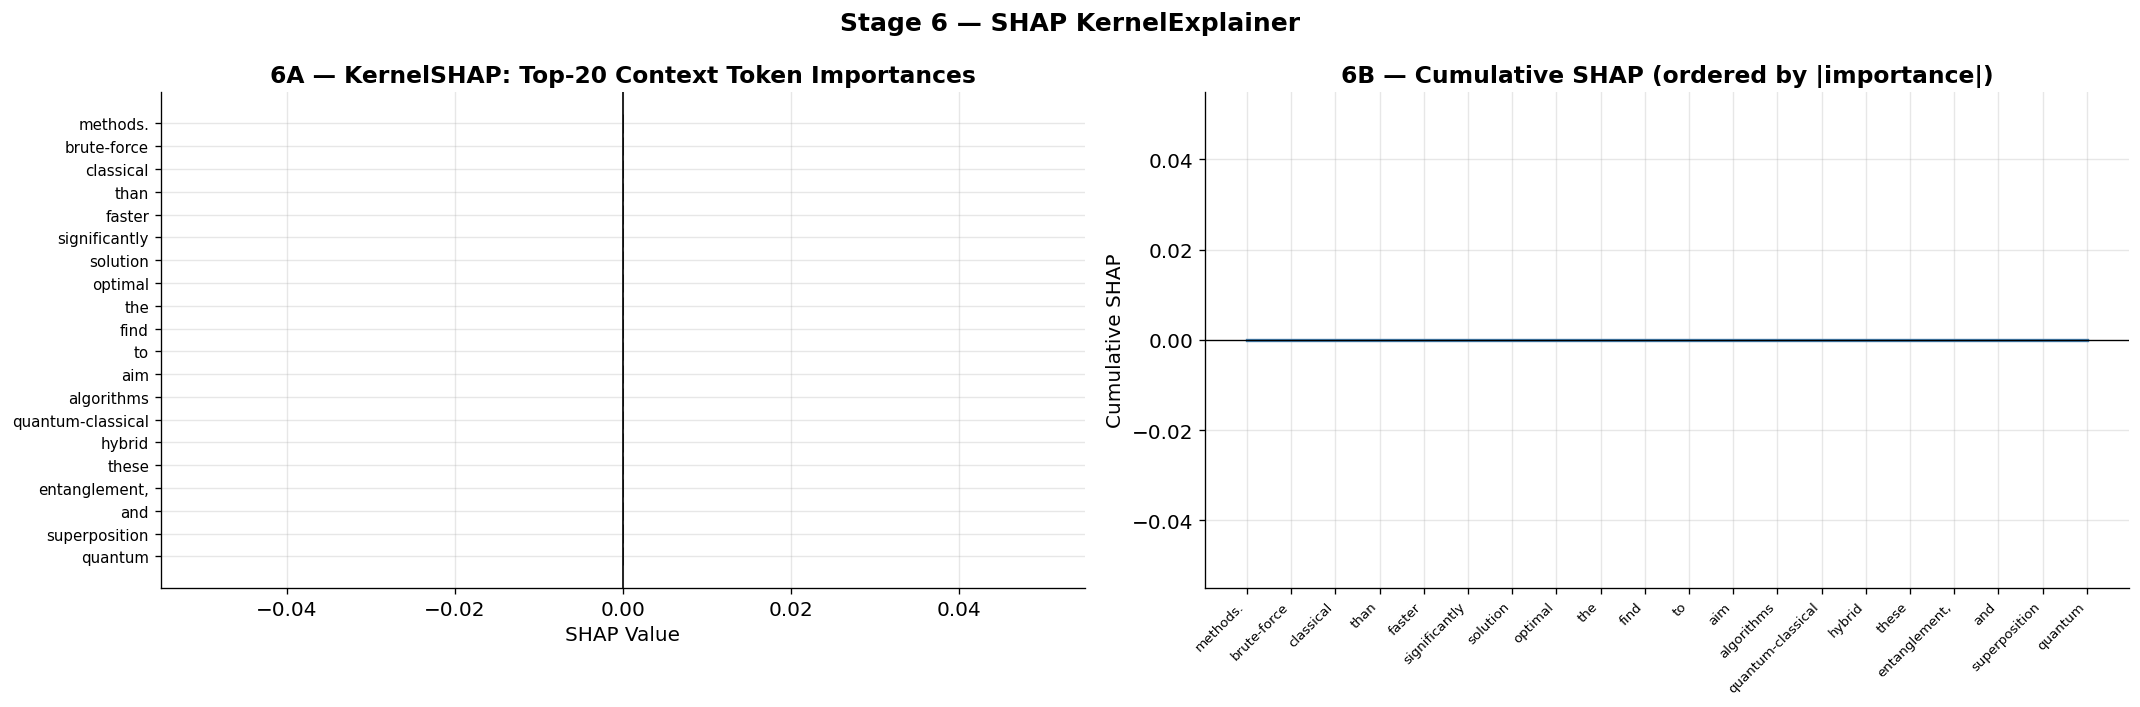

In [18]:
# ── Fig 6: SHAP ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sorted_idx = np.argsort(np.abs(shap_vals))[::-1]
top_k = 20
top_idx   = sorted_idx[:top_k]
top_words_s = [context_words[i] for i in top_idx]
top_shap  = shap_vals[top_idx]

# Left: bar chart
ax = axes[0]
colors = ['#27ae60' if v > 0 else '#c0392b' for v in top_shap]
ax.barh(range(top_k), top_shap, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_k)); ax.set_yticklabels(top_words_s, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('SHAP Value')
ax.set_title('6A — KernelSHAP: Top-20 Context Token Importances')

# Right: waterfall-style cumulative SHAP
ax = axes[1]
cum = np.cumsum(top_shap)
ax.step(range(top_k), cum, where='mid', color='steelblue', linewidth=2)
ax.fill_between(range(top_k), 0, cum, step='mid', alpha=0.25, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(top_k))
ax.set_xticklabels(top_words_s, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Cumulative SHAP')
ax.set_title('6B — Cumulative SHAP (ordered by |importance|)')

fig.suptitle('Stage 6 — SHAP KernelExplainer', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig06_shap')

In [19]:
# ── Occlusion sensitivity ─────────────────────────────────────────────────────
def span_confidence(q, ctx, s_idx, e_idx):
    enc = tokenizer(q, ctx, return_tensors='pt', truncation=True, max_length=512)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        out = model(**enc)
    s_p = torch.softmax(out.start_logits, dim=-1)[0].cpu()
    e_p = torch.softmax(out.end_logits,   dim=-1)[0].cpu()
    s_i = min(s_idx, len(s_p)-1)
    e_i = min(e_idx, len(e_p)-1)
    return float(s_p[s_i] * e_p[e_i])

baseline_conf = span_confidence(question, context, ORIG_S, ORIG_E)
occlusion_scores = []

for i, word in enumerate(context_words):
    perturbed = context_words[:i] + [tokenizer.mask_token] + context_words[i+1:]
    new_conf  = span_confidence(question, ' '.join(perturbed), ORIG_S, ORIG_E)
    occlusion_scores.append(baseline_conf - new_conf)  # positive = word was important

occlusion_scores = np.array(occlusion_scores)
print(f"Baseline span confidence: {baseline_conf:.6f}")
print(f"Max occlusion drop: {occlusion_scores.max():.6f}  "
      f"(word: '{context_words[np.argmax(occlusion_scores)]}'  )")

Baseline span confidence: 0.940366
Max occlusion drop: 0.940366  (word: 'Approximate'  )


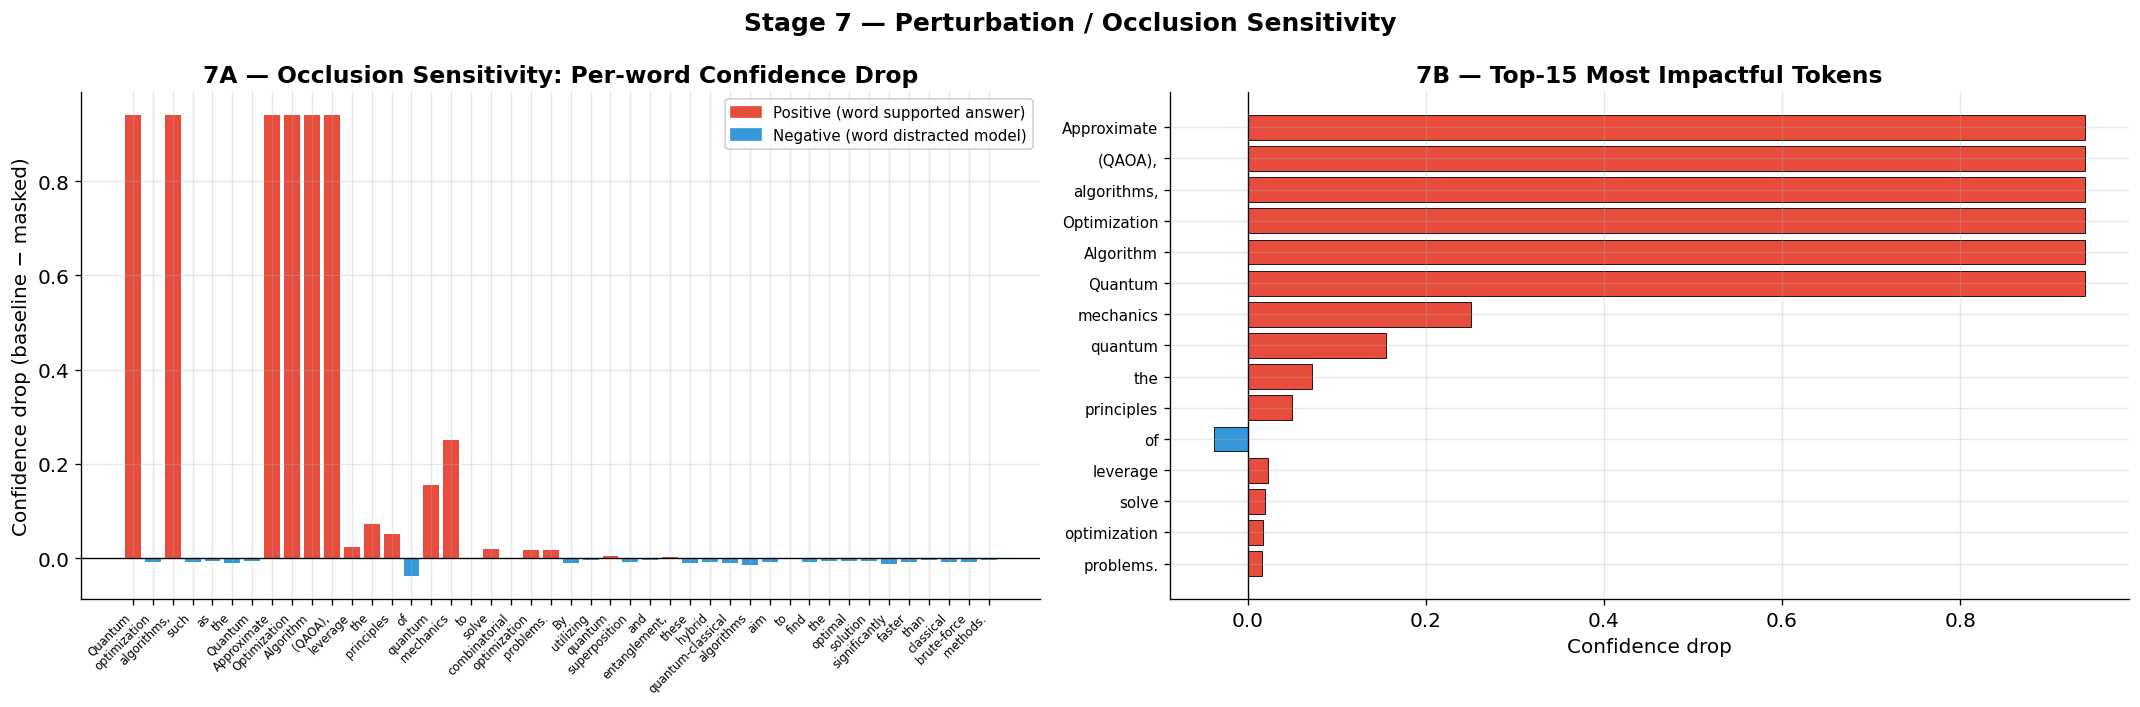

In [20]:
# ── Fig 7: Occlusion sensitivity ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: word-level drop bar chart
ax = axes[0]
xs = range(len(context_words))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in occlusion_scores]
ax.bar(xs, occlusion_scores, color=colors, edgecolor='none')
ax.set_xticks(xs)
ax.set_xticklabels(context_words, rotation=45, ha='right', fontsize=7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Confidence drop (baseline − masked)')
ax.set_title('7A — Occlusion Sensitivity: Per-word Confidence Drop')
pos_patch = mpatches.Patch(color='#e74c3c', label='Positive (word supported answer)')
neg_patch = mpatches.Patch(color='#3498db', label='Negative (word distracted model)')
ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

# Right: top-15 most impactful words
ax = axes[1]
top_idx_occ = np.argsort(np.abs(occlusion_scores))[::-1][:15]
top_w   = [context_words[i] for i in top_idx_occ]
top_d   = occlusion_scores[top_idx_occ]
colors2 = ['#e74c3c' if v > 0 else '#3498db' for v in top_d]
ax.barh(range(15), top_d, color=colors2, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(15)); ax.set_yticklabels(top_w, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Confidence drop')
ax.set_title('7B — Top-15 Most Impactful Tokens')

fig.suptitle('Stage 7 — Perturbation / Occlusion Sensitivity', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig07_occlusion')

In [21]:
# ── Build two ranked word lists (IG-based & Occlusion-based) ──────────────────
def get_word_ig_scores():
    """Map IG token scores back to context words (approximate)."""
    word_scores = {}
    for i, t in enumerate(tokens):
        clean = re.sub(r'[^a-zA-Z0-9]', '', t.replace('Ġ', '')).lower()
        if clean and t not in SPECIAL:
            word_scores[clean] = max(word_scores.get(clean, 0), abs(ig_avg_scores[i]))
    return word_scores

ig_word_scores = get_word_ig_scores()
ranked_by_ig  = sorted(context_words, key=lambda w: ig_word_scores.get(
    re.sub(r'[^a-zA-Z0-9]', '', w.lower()), 0), reverse=True)
ranked_by_occ = [context_words[i] for i in np.argsort(occlusion_scores)[::-1]]

masking_steps = list(range(0, min(16, N_CONTEXT_WORDS), 1))

def progressive_mask_confidence(ranked_words, steps):
    confs = [baseline_conf]
    words_lower = [re.sub(r'[^a-zA-Z0-9]', '', w.lower()) for w in ranked_words]
    for k in steps[1:]:
        to_mask = set(words_lower[:k])
        perturbed = [
            tokenizer.mask_token
            if re.sub(r'[^a-zA-Z0-9]', '', w.lower()) in to_mask else w
            for w in context_words
        ]
        confs.append(span_confidence(question, ' '.join(perturbed), ORIG_S, ORIG_E))
    return confs

conf_ig  = progressive_mask_confidence(ranked_by_ig, masking_steps)
conf_occ = progressive_mask_confidence(ranked_by_occ, masking_steps)

# Random baseline
rand_words = context_words.copy()
np.random.shuffle(rand_words)
conf_rand = progressive_mask_confidence(rand_words, masking_steps)

print("Progressive masking complete ✅")

Progressive masking complete ✅


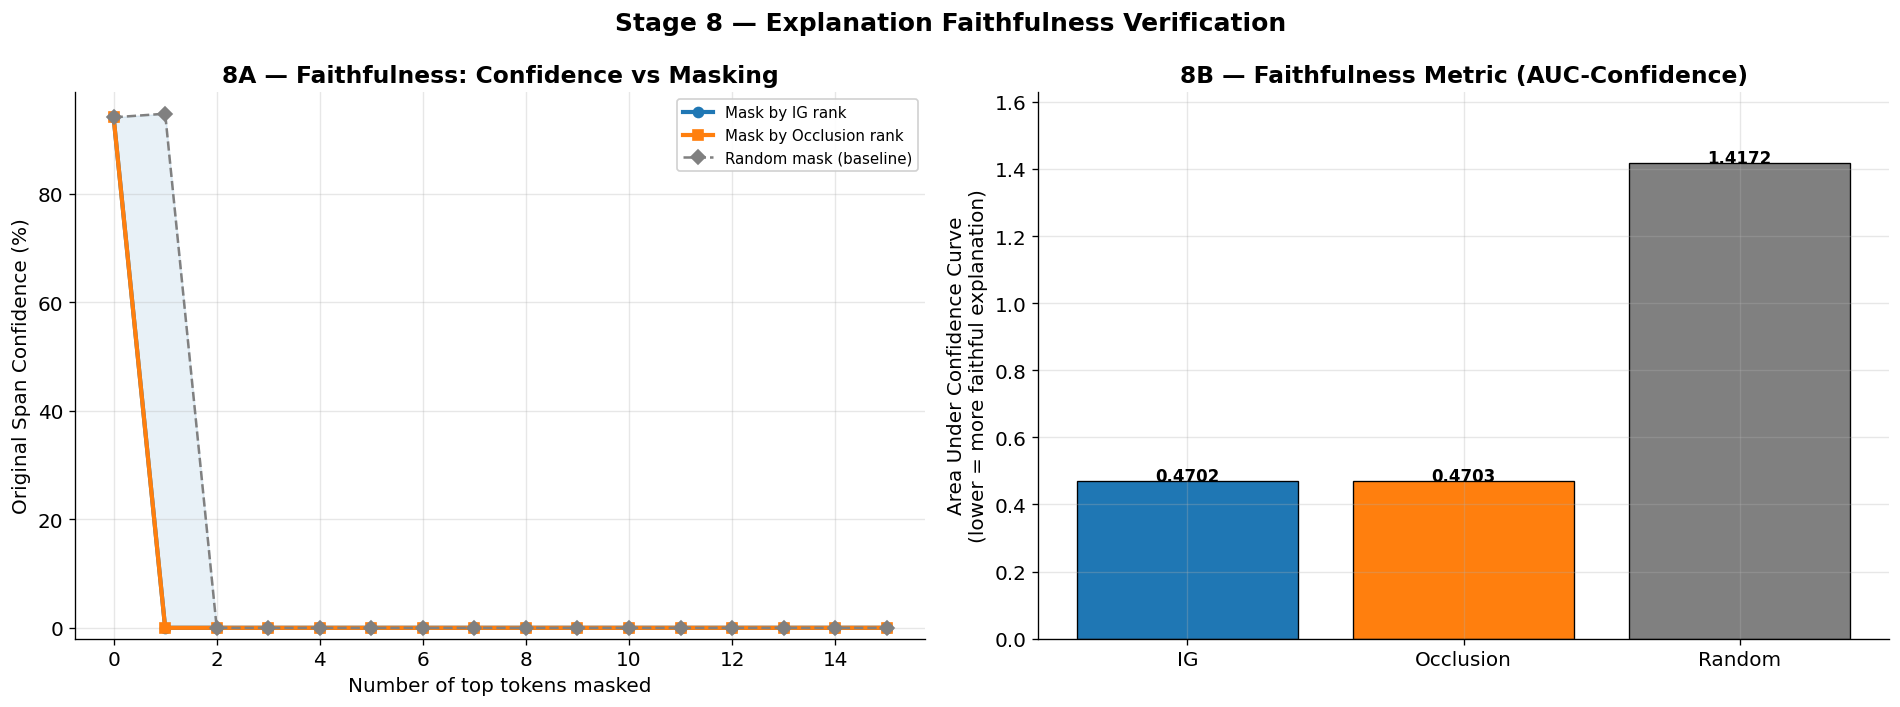

In [22]:
# ── Fig 8: Faithfulness ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: absolute confidence
ax = axes[0]
ax.plot(masking_steps, np.array(conf_ig)*100,  'o-', color=PALETTE[0], linewidth=2.5, label='Mask by IG rank')
ax.plot(masking_steps, np.array(conf_occ)*100, 's-', color=PALETTE[1], linewidth=2.5, label='Mask by Occlusion rank')
ax.plot(masking_steps, np.array(conf_rand)*100,'D--', color='gray',     linewidth=1.5, label='Random mask (baseline)')
ax.fill_between(masking_steps, np.array(conf_ig)*100, np.array(conf_rand)*100, alpha=0.1, color=PALETTE[0])
ax.set_xlabel('Number of top tokens masked')
ax.set_ylabel('Original Span Confidence (%)')
ax.set_title('8A — Faithfulness: Confidence vs Masking')
ax.legend(fontsize=9)
ax.set_ylim(-2, max(conf_ig[0], conf_occ[0])*105)

# Right: AUC-style "area over curve" metric
ax = axes[1]
aoc_ig   = float(np.trapz(np.array(conf_ig),   masking_steps))
aoc_occ  = float(np.trapz(np.array(conf_occ),  masking_steps))
aoc_rand = float(np.trapz(np.array(conf_rand), masking_steps))
metrics = {'IG': aoc_ig, 'Occlusion': aoc_occ, 'Random': aoc_rand}
bars = ax.bar(metrics.keys(), metrics.values(),
              color=[PALETTE[0], PALETTE[1], 'gray'], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Area Under Confidence Curve\n(lower = more faithful explanation)')
ax.set_title('8B — Faithfulness Metric (AUC-Confidence)')
ax.set_ylim(0, max(metrics.values()) * 1.15)

fig.suptitle('Stage 8 — Explanation Faithfulness Verification', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig08_faithfulness')

In [23]:
# ── Greedy counterfactual search ──────────────────────────────────────────────
def get_predicted_span(q, ctx):
    enc = tokenizer(q, ctx, return_tensors='pt', truncation=True)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        out = model(**enc)
    s = int(torch.argmax(out.start_logits))
    e = int(torch.argmax(out.end_logits))
    toks = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    ans = tokenizer.convert_tokens_to_string([t.replace('Ġ', ' ') for t in toks[s:e+1]]).strip()
    return ans, s, e

original_span, _, _ = get_predicted_span(question, context)

# Rank words by occlusion (most important first)
words_by_importance = [context_words[i] for i in np.argsort(occlusion_scores)[::-1]]

cf_log = []  # (word_removed, new_answer, n_words_changed)
current_words = context_words.copy()
changed = []

for target_word in words_by_importance:
    idx = next((i for i, w in enumerate(current_words) if w == target_word), None)
    if idx is None:
        continue
    trial = current_words[:idx] + [tokenizer.mask_token] + current_words[idx+1:]
    new_ctx = ' '.join(trial)
    new_ans, ns, ne = get_predicted_span(question, new_ctx)
    cf_log.append({
        'word_masked': target_word,
        'new_answer': new_ans,
        'answer_changed': new_ans.strip().lower() != original_span.strip().lower(),
        'n_changes': len(changed) + 1
    })
    changed.append(idx)
    current_words = trial
    if new_ans.strip().lower() != original_span.strip().lower():
        cf_words_needed = len(changed)
        print(f"✅ Counterfactual found after masking {cf_words_needed} word(s).")
        print(f"   Masked words: {[context_words[i] for i in changed]}")
        print(f"   Original answer: '{original_span}'")
        print(f"   Counterfactual answer: '{new_ans}'")
        break
else:
    print("ℹ️  No full counterfactual found within search budget.")
    cf_words_needed = len(changed)

✅ Counterfactual found after masking 7 word(s).
   Masked words: ['Approximate', '(QAOA),', 'algorithms,', 'Optimization', 'Algorithm', 'Quantum', 'mechanics']
   Original answer: 'quantum mechanics'
   Counterfactual answer: 'quantum<mask>'


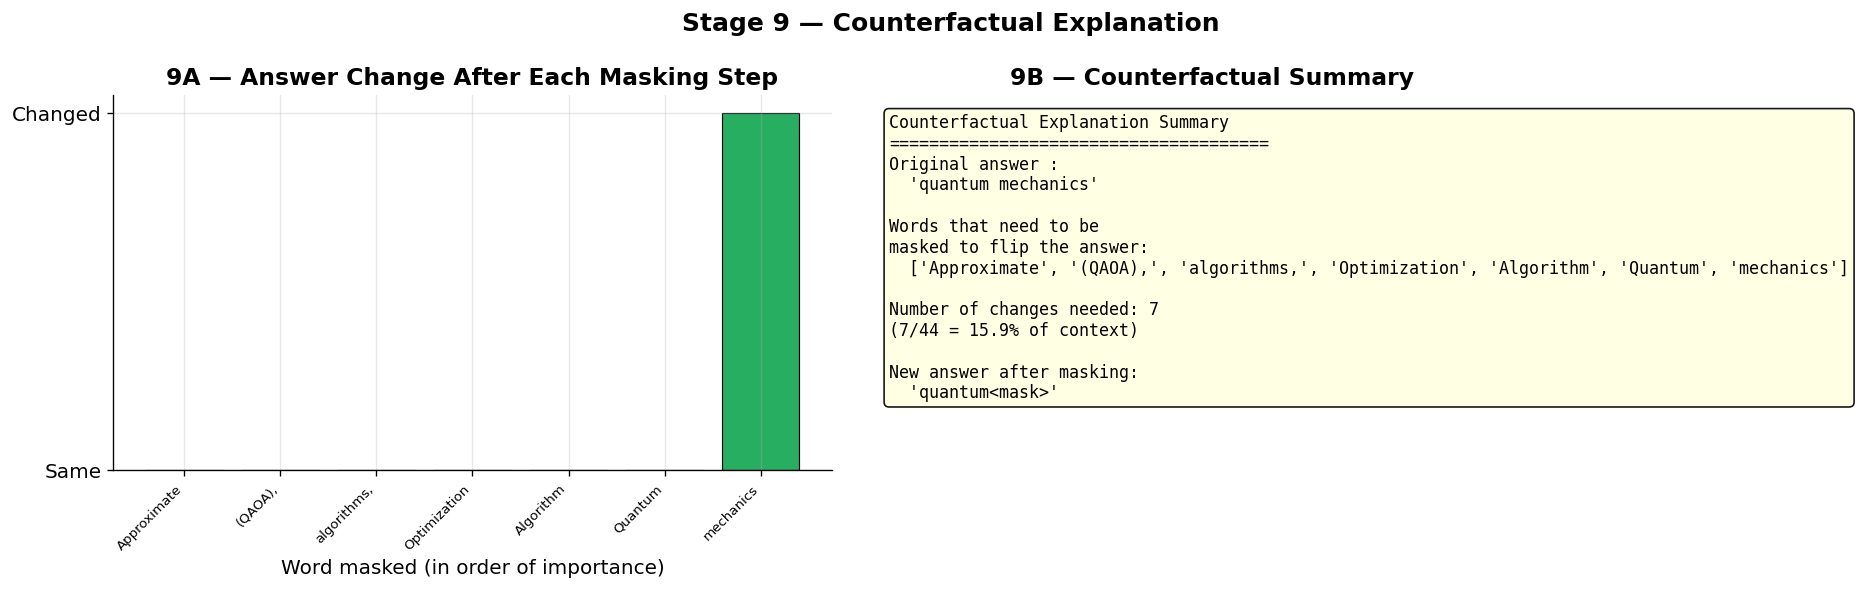

In [24]:
# ── Fig 9: Counterfactual trace ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: did answer change?
ax = axes[0]
changed_flags = [int(r['answer_changed']) for r in cf_log]
n_steps = min(15, len(cf_log))
ax.bar(range(n_steps), changed_flags[:n_steps],
       color=['#27ae60' if c else '#e74c3c' for c in changed_flags[:n_steps]],
       edgecolor='black', linewidth=0.7)
ax.set_xticks(range(n_steps))
ax.set_xticklabels([r['word_masked'] for r in cf_log[:n_steps]],
                   rotation=45, ha='right', fontsize=8)
ax.set_yticks([0, 1]); ax.set_yticklabels(['Same', 'Changed'])
ax.set_xlabel('Word masked (in order of importance)')
ax.set_title('9A — Answer Change After Each Masking Step')

# Right: summary text box
ax = axes[1]
ax.axis('off')
summary_text = (
    f"Counterfactual Explanation Summary\n"
    f"{'='*38}\n"
    f"Original answer :\n  '{original_span}'\n\n"
    f"Words that need to be\n"
    f"masked to flip the answer:\n"
    f"  {[context_words[i] for i in changed[:cf_words_needed]]}\n\n"
    f"Number of changes needed: {cf_words_needed}\n"
    f"({cf_words_needed}/{N_CONTEXT_WORDS} = "
    f"{100*cf_words_needed/N_CONTEXT_WORDS:.1f}% of context)\n\n"
    f"New answer after masking:\n"
    f"  '{cf_log[cf_words_needed-1]['new_answer'] if cf_log else 'N/A'}'"
)
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax.set_title('9B — Counterfactual Summary')

fig.suptitle('Stage 9 — Counterfactual Explanation', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig09_counterfactual')

In [25]:
# ── Extract final hidden states ───────────────────────────────────────────────
final_hidden = outputs.hidden_states[-1][0].detach().cpu().numpy()  # (seq, 1024)
sep_idx      = tokens.index(tokenizer.sep_token)

# Colour labels
token_labels = []
for i in range(N_TOKENS):
    if tokens[i] in (tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token):
        token_labels.append('Special')
    elif i <= sep_idx:
        token_labels.append('Question')
    elif ORIG_S <= i <= ORIG_E:
        token_labels.append('Answer')
    else:
        token_labels.append('Context')

label_colors = {'Special': 'gray', 'Question': 'royalblue',
                'Answer': 'crimson', 'Context': 'mediumseagreen'}
colors_plot  = [label_colors[l] for l in token_labels]

# PCA
pca = PCA(n_components=2, random_state=SEED)
pca_2d = pca.fit_transform(final_hidden)

# t-SNE (fewer components = 2, perplexity capped at n_samples-1)
perp = min(30, N_TOKENS - 1)
tsne = TSNE(n_components=2, perplexity=perp, random_state=SEED, n_iter=500)
tsne_2d = tsne.fit_transform(final_hidden)

print(f"PCA variance explained: {np.sum(pca.explained_variance_ratio_)*100:.1f}%")

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7988f420fe20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


PCA variance explained: 38.2%


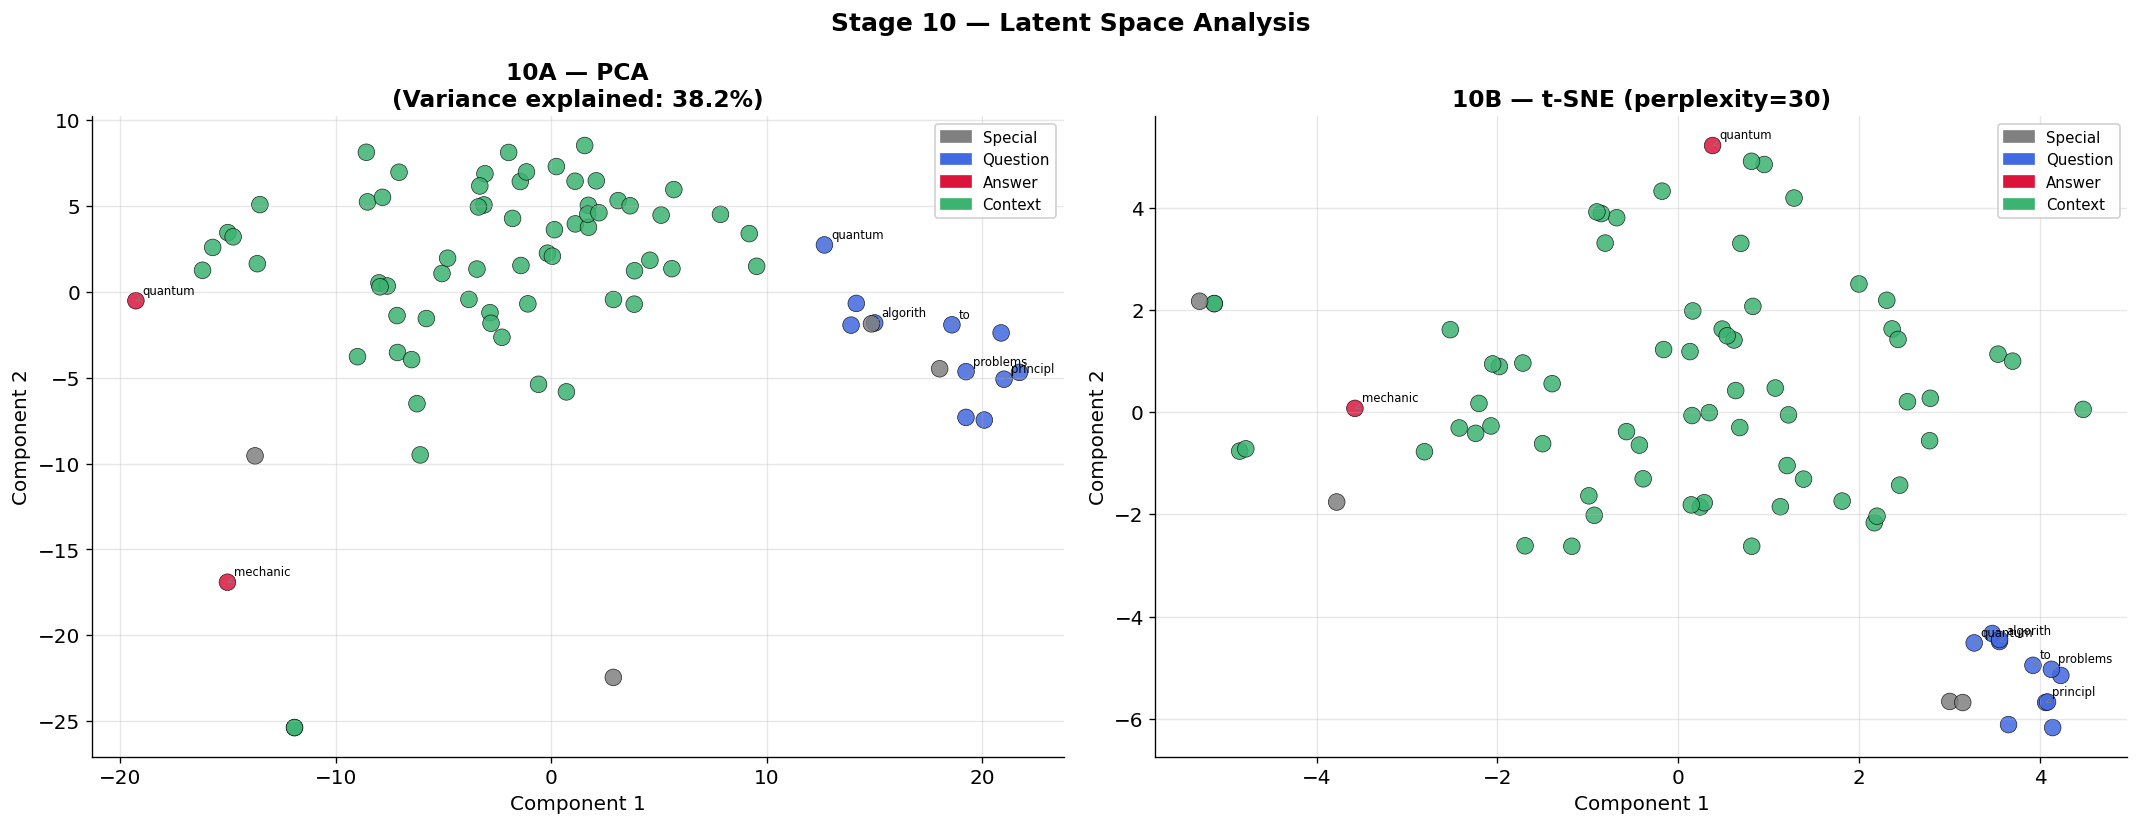

In [26]:
# ── Fig 10: Latent space ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, proj, title in zip(
    axes,
    [pca_2d, tsne_2d],
    [f'10A — PCA\n(Variance explained: {np.sum(pca.explained_variance_ratio_)*100:.1f}%)',
     '10B — t-SNE (perplexity={perp})']
):
    ax.scatter(
        proj[:, 0], proj[:, 1],
        c=colors_plot, s=100, edgecolors='k', linewidth=0.4, alpha=0.85
    )
    # Annotate answer & some question tokens
    for i, (tok, lbl) in enumerate(zip(tokens, token_labels)):
        if lbl == 'Answer' or (lbl == 'Question' and i % 2 == 0):
            clean = re.sub(r'[^a-zA-Z0-9]', '', tok.replace('Ġ', ''))[:8]
            if clean:
                ax.annotate(clean,
                            (proj[i, 0], proj[i, 1]),
                            textcoords='offset points', xytext=(4, 4),
                            fontsize=7, color='black',
                            arrowprops=dict(arrowstyle='->', lw=0.5, color='gray'))
    handles = [mpatches.Patch(color=v, label=k) for k, v in label_colors.items()]
    ax.legend(handles=handles, fontsize=9, loc='best')
    ax.set_title(title.format(perp=perp))
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')

fig.suptitle('Stage 10 — Latent Space Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig10_latent_space')

In [27]:
# ── Attention mass on answer per layer ───────────────────────────────────────
answer_mass = []
for layer_attn in outputs.attentions:
    avg_head = torch.mean(layer_attn[0], dim=0)  # (seq, seq)
    ans_mass  = torch.sum(avg_head[:, ORIG_S:ORIG_E+1]).item()
    answer_mass.append(ans_mass)

# CLS hidden state across layers (norm as proxy for info accumulation)
cls_norms = []
for hs in outputs.hidden_states:
    cls_norms.append(hs[0, 0, :].cpu().norm().item())

# Layer-wise mean representation norm (whole sequence)
layer_seq_norms = [
    hs[0].cpu().norm(dim=-1).mean().item()
    for hs in outputs.hidden_states
]

print("Cognitive progression metrics extracted ✅")

Cognitive progression metrics extracted ✅


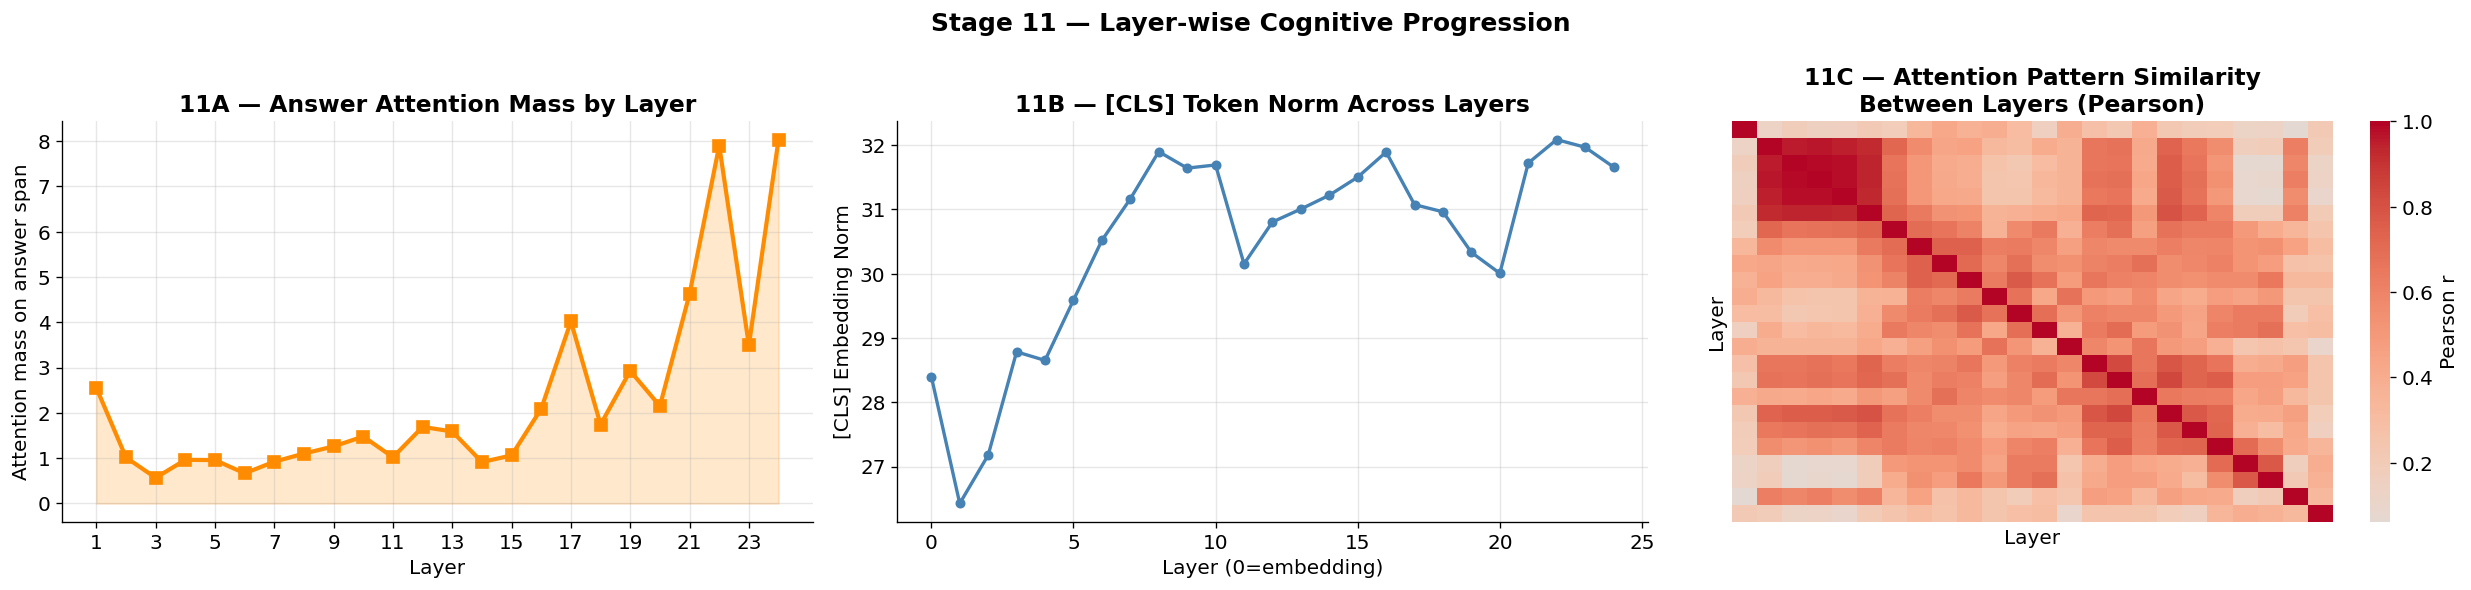

In [28]:
# ── Fig 11: Cognitive progression ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

layers_x = list(range(1, N_LAYERS + 1))

# 11A: answer attention mass
ax = axes[0]
ax.plot(layers_x, answer_mass, 's-', color='darkorange', linewidth=2.5, markersize=7)
ax.fill_between(layers_x, 0, answer_mass, alpha=0.2, color='darkorange')
ax.set_xlabel('Layer'); ax.set_ylabel('Attention mass on answer span')
ax.set_title('11A — Answer Attention Mass by Layer')
ax.set_xticks(range(1, N_LAYERS+1, 2))

# 11B: CLS norm
ax = axes[1]
ax.plot(range(len(cls_norms)), cls_norms, 'o-', color='steelblue', linewidth=2, markersize=5)
ax.set_xlabel('Layer (0=embedding)'); ax.set_ylabel('[CLS] Embedding Norm')
ax.set_title('11B — [CLS] Token Norm Across Layers')

# 11C: heatmap of attention pattern similarity across layers
ax = axes[2]
LIMIT2 = min(25, SEQ)
layer_attn_mats = [
    all_attn[l].mean(dim=0)[:LIMIT2, :LIMIT2].numpy().flatten()
    for l in range(N_LAYERS)
]
layer_corr = np.corrcoef(layer_attn_mats)  # (N_LAYERS, N_LAYERS)
sns.heatmap(layer_corr, ax=ax, cmap='coolwarm', center=0,
            cbar_kws={'label': 'Pearson r'}, xticklabels=False, yticklabels=False)
ax.set_xlabel('Layer'); ax.set_ylabel('Layer')
ax.set_title('11C — Attention Pattern Similarity\nBetween Layers (Pearson)')

fig.suptitle('Stage 11 — Layer-wise Cognitive Progression', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig11_cognitive_progression')

In [29]:
# ── Head statistics ───────────────────────────────────────────────────────────
# Local attention bias: ratio of mass on tokens within distance ≤ 3
locality_scores = np.zeros((N_LAYERS, N_HEADS))
for l in range(N_LAYERS):
    for h in range(N_HEADS):
        a = all_attn[l, h].numpy()   # (seq, seq)
        local_mask = np.abs(
            np.arange(SEQ)[:, None] - np.arange(SEQ)[None, :]
        ) <= 3
        locality_scores[l, h] = a[local_mask].sum() / (a.sum() + 1e-9)

# Most focused head (lowest entropy overall)
flat_best = np.unravel_index(np.argmin(head_entropies), head_entropies.shape)
best_layer, best_head = flat_best
print(f"Most focused head: layer {best_layer+1}, head {best_head}  "
      f"(entropy={head_entropies[best_layer, best_head]:.3f})")

Most focused head: layer 3, head 10  (entropy=0.000)


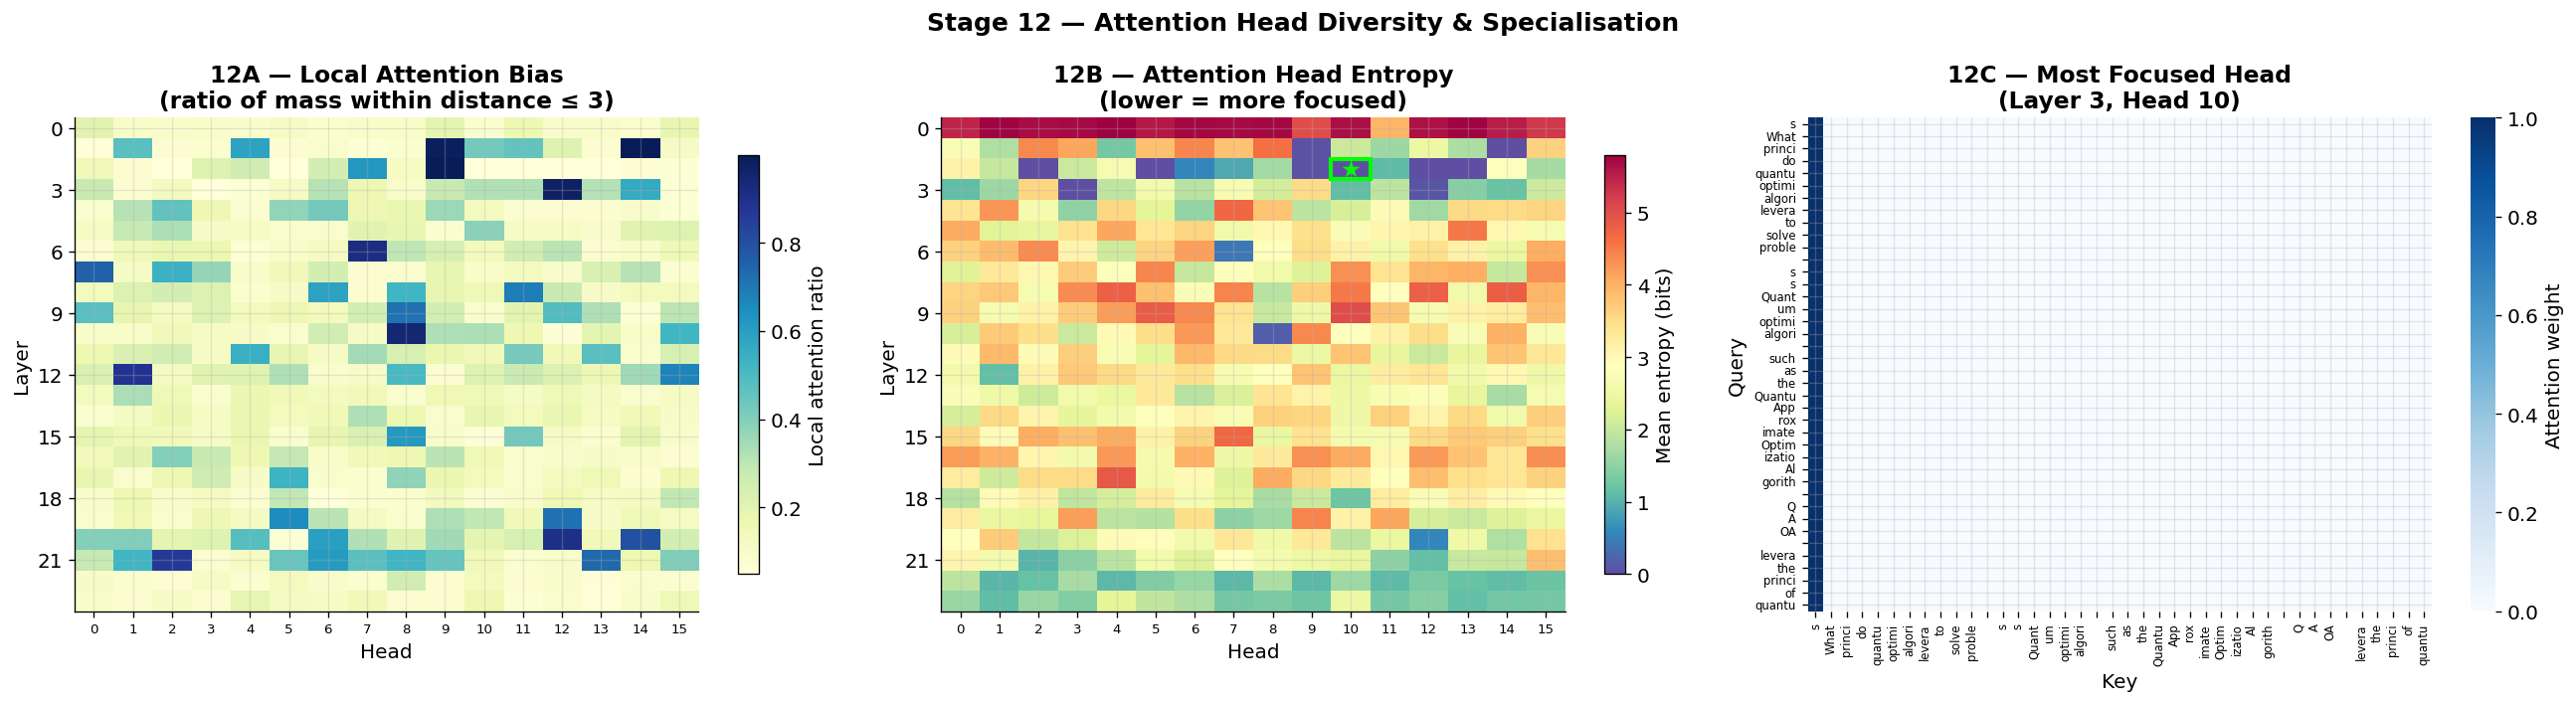

In [30]:
# ── Fig 12: Head diversity ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 12A: locality heatmap
im = axes[0].imshow(locality_scores, aspect='auto', cmap='YlGnBu')
plt.colorbar(im, ax=axes[0], shrink=0.85, label='Local attention ratio')
axes[0].set_xlabel('Head'); axes[0].set_ylabel('Layer')
axes[0].set_title('12A — Local Attention Bias\n(ratio of mass within distance ≤ 3)')
axes[0].set_xticks(range(N_HEADS)); axes[0].set_xticklabels(range(N_HEADS), fontsize=8)
axes[0].set_yticks(range(0, N_LAYERS, 3))

# 12B: entropy heatmap  (already computed in stage 4)
im2 = axes[1].imshow(head_entropies, aspect='auto', cmap='Spectral_r')
plt.colorbar(im2, ax=axes[1], shrink=0.85, label='Mean entropy (bits)')
axes[1].set_xlabel('Head'); axes[1].set_ylabel('Layer')
axes[1].set_title('12B — Attention Head Entropy\n(lower = more focused)')
axes[1].set_xticks(range(N_HEADS)); axes[1].set_xticklabels(range(N_HEADS), fontsize=8)
axes[1].set_yticks(range(0, N_LAYERS, 3))
# Mark the most focused head
axes[1].add_patch(plt.Rectangle((best_head-0.5, best_layer-0.5), 1, 1,
                                  fill=False, edgecolor='lime', lw=2.5))
axes[1].text(best_head, best_layer, '★', ha='center', va='center',
             color='lime', fontsize=14, fontweight='bold')

# 12C: best head's attention pattern
ax = axes[2]
best_attn = all_attn[best_layer, best_head].numpy()[:LIMIT, :LIMIT]
sns.heatmap(best_attn, ax=ax, cmap='Blues',
            xticklabels=clean_axis, yticklabels=clean_axis,
            cbar_kws={'label': 'Attention weight'})
ax.set_title(f'12C — Most Focused Head\n(Layer {best_layer+1}, Head {best_head})')
ax.set_xlabel('Key'); ax.set_ylabel('Query')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Stage 12 — Attention Head Diversity & Specialisation', fontsize=15, fontweight='bold')
plt.tight_layout()
save_or_show(fig, 'fig12_head_diversity')

In [31]:
from scipy.stats import spearmanr

# ── Align all methods on context_words ───────────────────────────────────────
def method_scores_per_word(ig_dict, gxi_dict_=None):
    """Build (N_CONTEXT_WORDS,) arrays for each method."""
    ig_arr   = np.array([ig_dict.get(re.sub(r'[^a-zA-Z0-9]', '', w.lower()), 0)
                         for w in context_words])
    occ_arr  = occlusion_scores.copy()
    shap_arr = shap_vals.copy()

    # Map token-level GxI back to context words (max over sub-tokens)
    gxi_word = {}
    for i, t in enumerate(tokens):
        c = re.sub(r'[^a-zA-Z0-9]', '', t.replace('Ġ', '')).lower()
        if c and t not in SPECIAL:
            gxi_word[c] = max(gxi_word.get(c, 0), abs(gxi_avg[i]))
    gxi_arr = np.array([gxi_word.get(re.sub(r'[^a-zA-Z0-9]', '', w.lower()), 0)
                        for w in context_words])

    # Min-max normalise all
    def mm(a):
        r = np.abs(a)
        mn, mx = r.min(), r.max()
        return (r - mn) / (mx - mn + 1e-9)

    return mm(ig_arr), mm(gxi_arr), mm(shap_arr), mm(occ_arr)

ig_w, gxi_w, shap_w, occ_w = method_scores_per_word(ig_word_scores)

# Spearman correlations
method_names = ['IG', 'Grad×Input', 'SHAP', 'Occlusion']
arrs = [ig_w, gxi_w, shap_w, occ_w]
corr_mat = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        r, _ = spearmanr(arrs[i], arrs[j])
        corr_mat[i, j] = r

print("Spearman rank correlations between methods:")
for i, n in enumerate(method_names):
    for j, m in enumerate(method_names):
        print(f"  {n:12s} vs {m:12s}: {corr_mat[i,j]:.3f}")

Spearman rank correlations between methods:
  IG           vs IG          : 1.000
  IG           vs Grad×Input  : 0.719
  IG           vs SHAP        : nan
  IG           vs Occlusion   : 0.113
  Grad×Input   vs IG          : 0.719
  Grad×Input   vs Grad×Input  : 1.000
  Grad×Input   vs SHAP        : nan
  Grad×Input   vs Occlusion   : 0.073
  SHAP         vs IG          : nan
  SHAP         vs Grad×Input  : nan
  SHAP         vs SHAP        : nan
  SHAP         vs Occlusion   : nan
  Occlusion    vs IG          : 0.113
  Occlusion    vs Grad×Input  : 0.073
  Occlusion    vs SHAP        : nan
  Occlusion    vs Occlusion   : 1.000


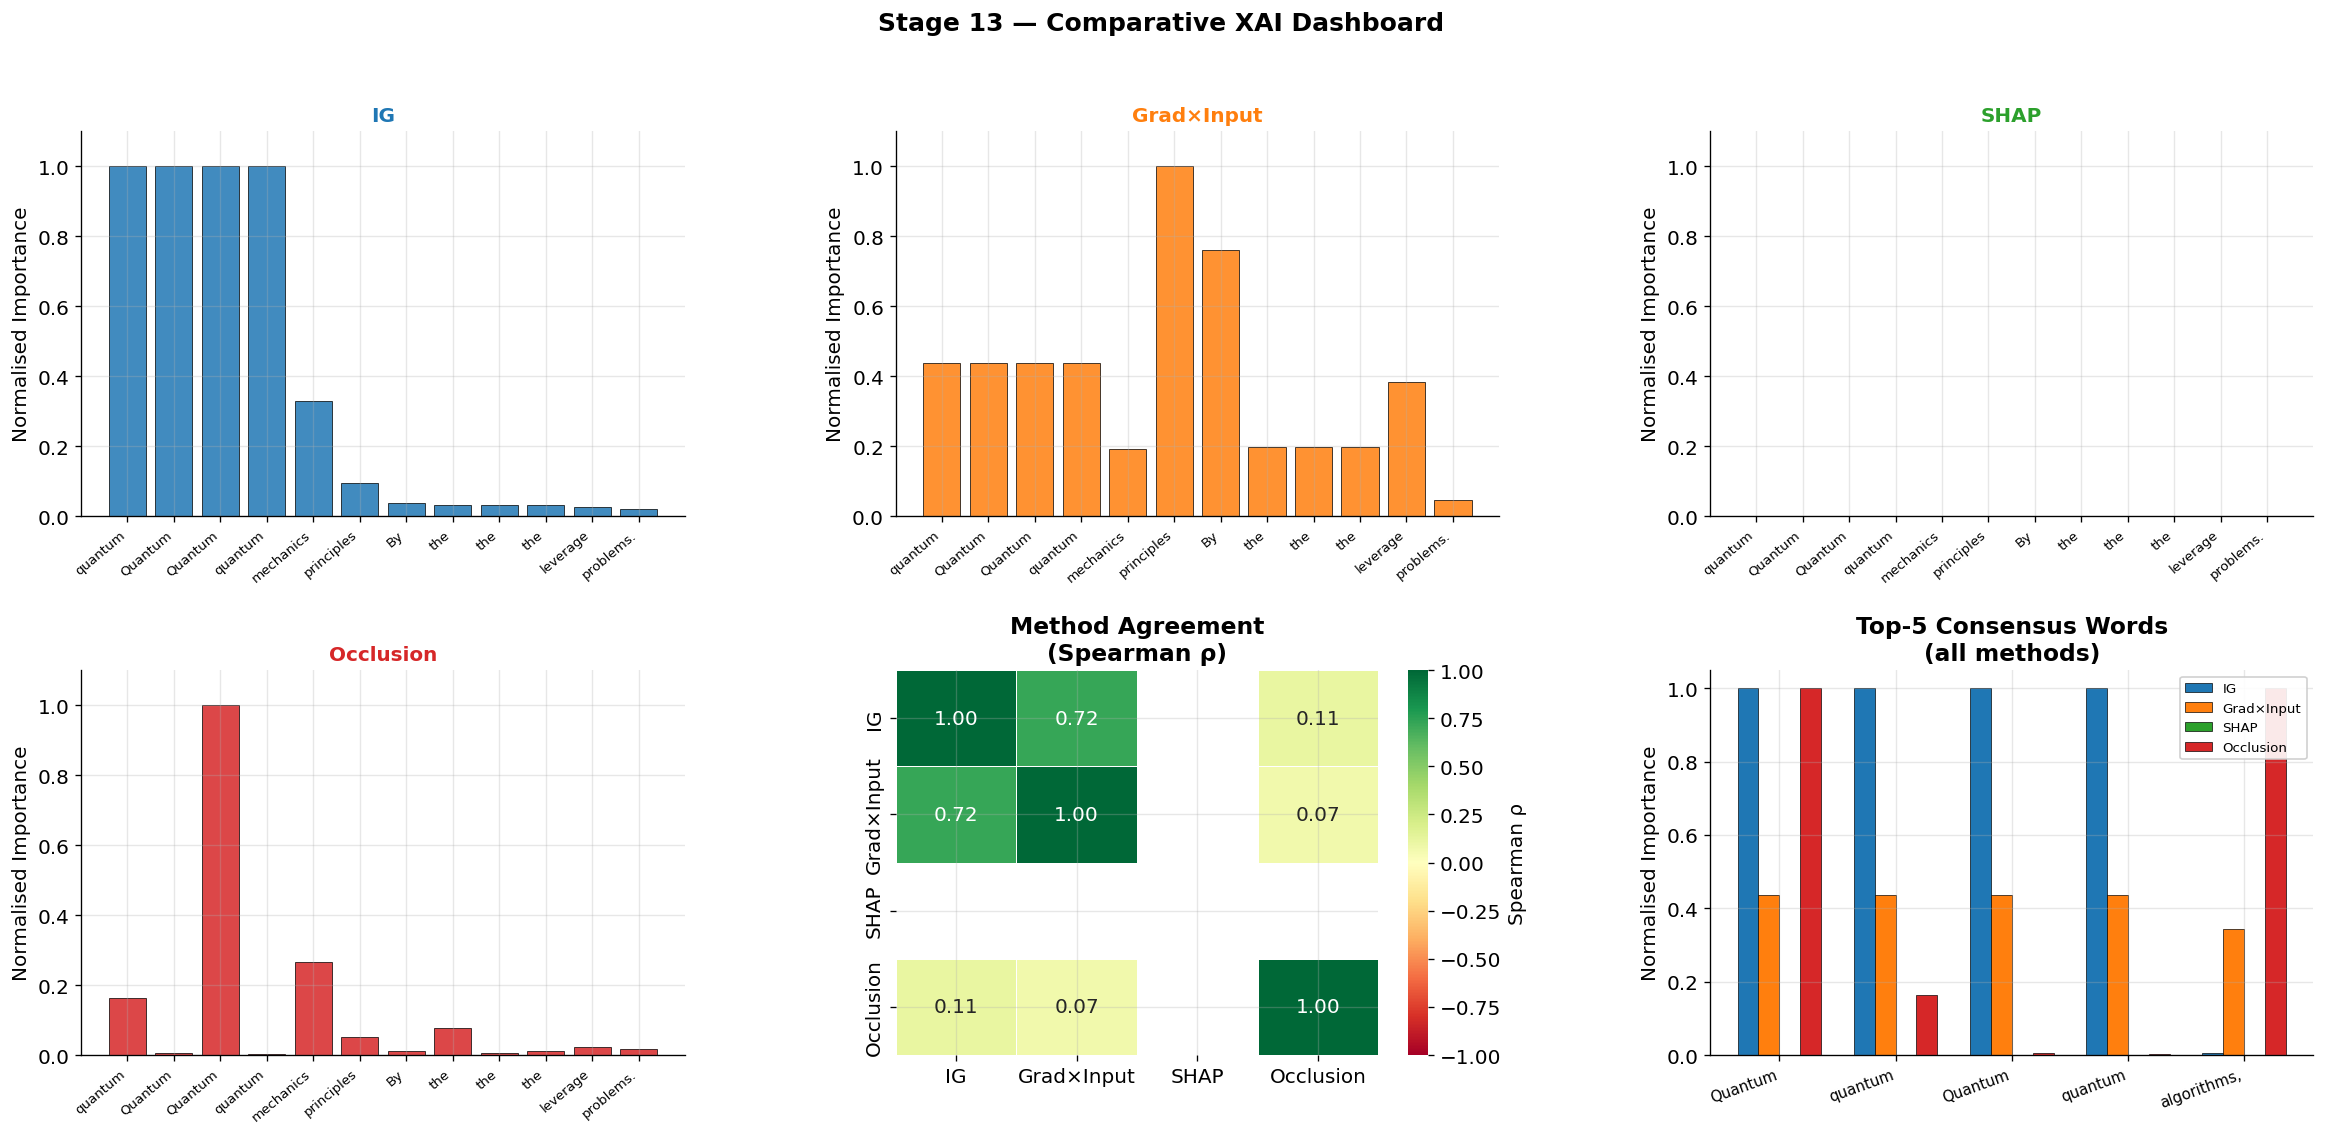

In [32]:
# ── Fig 13: Comparative dashboard ────────────────────────────────────────────
fig = plt.figure(figsize=(24, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Top row: four method bars side-by-side (top-12 words)
top12_idx = np.argsort(ig_w)[::-1][:12]
top12_words = [context_words[i] for i in top12_idx]

for col, (arr, name, color) in enumerate(zip(
    [ig_w, gxi_w, shap_w, occ_w],
    method_names,
    [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]
)):
    if col < 3:
        ax = fig.add_subplot(gs[0, col])
    else:
        ax = fig.add_subplot(gs[1, 0])
    vals_top = arr[top12_idx]
    ax.bar(range(12), vals_top, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(12))
    ax.set_xticklabels(top12_words, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Normalised Importance')
    ax.set_title(f'{name}', fontsize=12, color=color)
    ax.set_ylim(0, 1.1)

# Bottom-middle: correlation heatmap
ax_corr = fig.add_subplot(gs[1, 1])
mask_diag = np.eye(4, dtype=bool)
sns.heatmap(corr_mat, ax=ax_corr, annot=True, fmt='.2f',
            xticklabels=method_names, yticklabels=method_names,
            cmap='RdYlGn', vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Spearman ρ'})
ax_corr.set_title('Method Agreement\n(Spearman ρ)')

# Bottom-right: radar / multi-method bar for a single key word
ax_radar = fig.add_subplot(gs[1, 2])
# Find the word that's most consistently important across all methods
consensus = ig_w + gxi_w + shap_w + occ_w
top5_cons_idx = np.argsort(consensus)[::-1][:5]
top5_words = [context_words[i] for i in top5_cons_idx]
w = 0.18
x5 = np.arange(5)
for k, (arr, name, color) in enumerate(zip(arrs, method_names, PALETTE[:4])):
    ax_radar.bar(x5 + k*w, arr[top5_cons_idx], w, label=name, color=color,
                 edgecolor='black', linewidth=0.4)
ax_radar.set_xticks(x5 + 1.5*w)
ax_radar.set_xticklabels(top5_words, rotation=20, ha='right', fontsize=9)
ax_radar.set_ylabel('Normalised Importance')
ax_radar.set_title('Top-5 Consensus Words\n(all methods)')
ax_radar.legend(fontsize=8)

fig.suptitle('Stage 13 — Comparative XAI Dashboard', fontsize=15, fontweight='bold')
save_or_show(fig, 'fig13_comparative_dashboard')

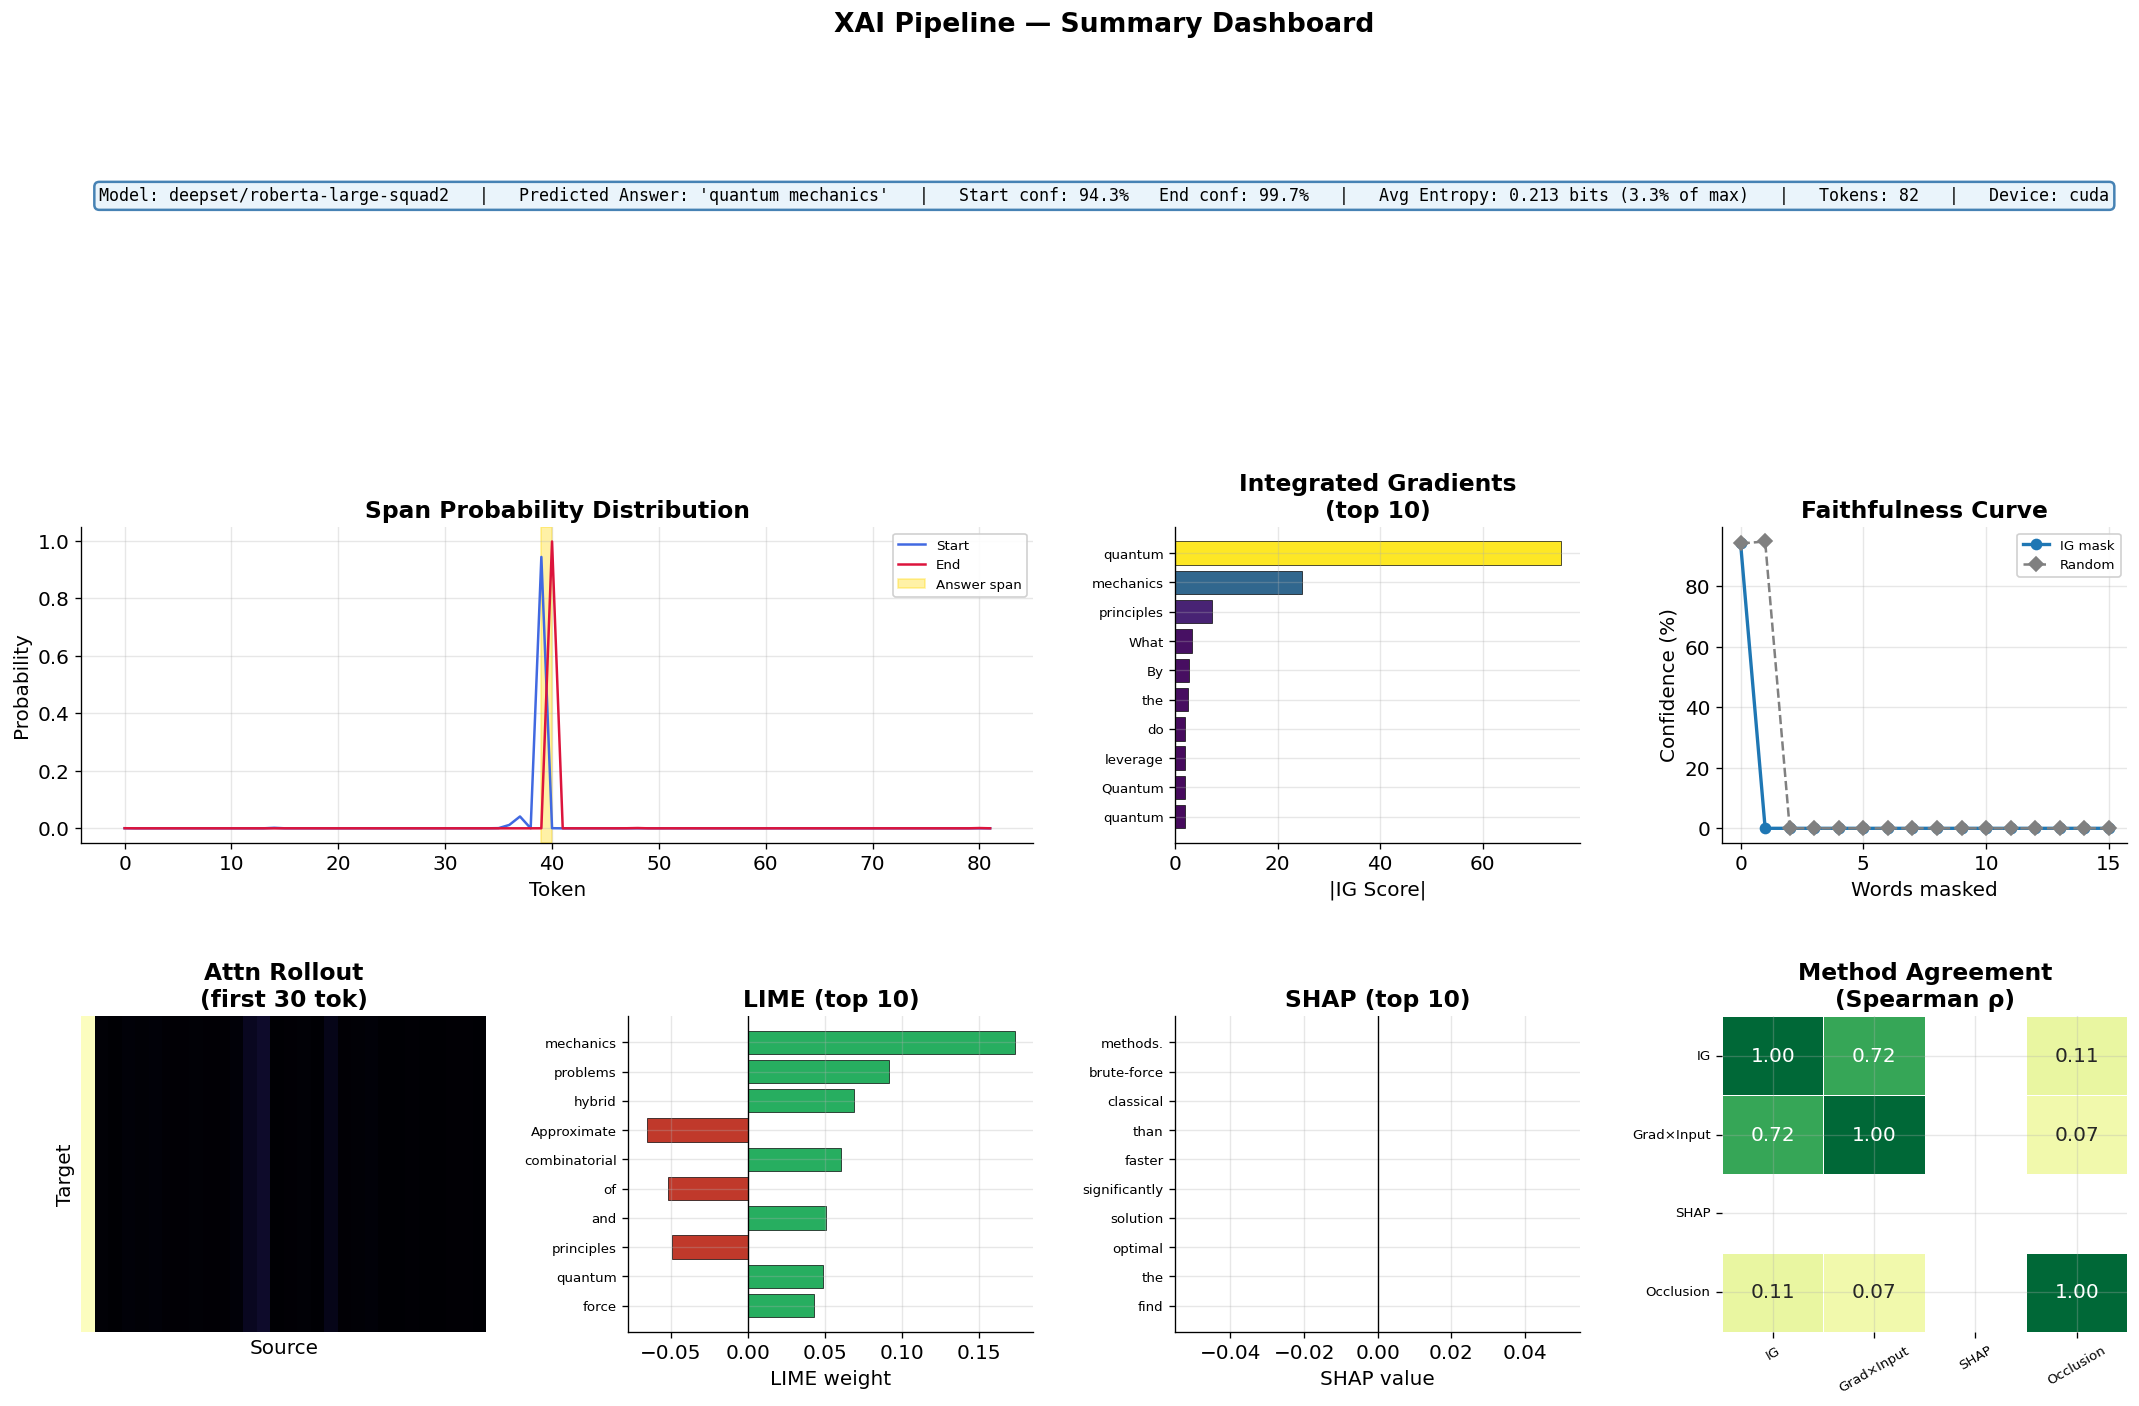

In [33]:
# ── Fig 14: Master summary card ───────────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.35)

# ─── Row 0: Model card ───────────────────────────────────────────────────────
ax_card = fig.add_subplot(gs[0, :])
ax_card.axis('off')
info = (
    f"Model: {MODEL_NAME}   |   "
    f"Predicted Answer: '{predicted_answer}'   |   "
    f"Start conf: {start_probs[ORIG_S]*100:.1f}%   "
    f"End conf: {end_probs[ORIG_E]*100:.1f}%   |   "
    f"Avg Entropy: {H_avg:.3f} bits ({norm_H*100:.1f}% of max)   |   "
    f"Tokens: {N_TOKENS}   |   Device: {DEVICE}"
)
ax_card.text(0.5, 0.5, info, ha='center', va='center', fontsize=10,
             transform=ax_card.transAxes, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#eaf4fb', edgecolor='steelblue', lw=1.5))
ax_card.set_title('XAI Pipeline — Summary Dashboard', fontsize=16, fontweight='bold', pad=4)

# ─── Row 1 left: Span probs ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
ax1.plot(start_probs, label='Start', color='royalblue', lw=1.5)
ax1.plot(end_probs,   label='End',   color='crimson',   lw=1.5)
ax1.axvspan(ORIG_S, ORIG_E, color='gold', alpha=0.35, label='Answer span')
ax1.set_xlabel('Token'); ax1.set_ylabel('Probability')
ax1.legend(fontsize=8); ax1.set_title('Span Probability Distribution')

# ─── Row 1 middle: IG top 10 ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2])
labs, vals = filter_tokens_scores(ig_avg_scores, keep_top=10)
norm_v = np.array(vals) / (max(vals)+1e-9)
ax2.barh(range(len(labs)), vals, color=cm.viridis(norm_v), edgecolor='black', lw=0.4)
ax2.set_yticks(range(len(labs))); ax2.set_yticklabels(labs, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('|IG Score|'); ax2.set_title('Integrated Gradients\n(top 10)')

# ─── Row 1 right: Faithfulness ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 3])
ax3.plot(masking_steps, np.array(conf_ig)*100,   'o-', color=PALETTE[0], lw=2, label='IG mask')
ax3.plot(masking_steps, np.array(conf_rand)*100, 'D--', color='gray', lw=1.5, label='Random')
ax3.set_xlabel('Words masked'); ax3.set_ylabel('Confidence (%)')
ax3.set_title('Faithfulness Curve'); ax3.legend(fontsize=8)

# ─── Row 2 left: Attention rollout ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
LIMIT3 = min(30, SEQ)
c3 = [re.sub(r'[^a-zA-Z0-9]', '', t)[:5] for t in tokens[:LIMIT3]]
sns.heatmap(rollout_mat[:LIMIT3, :LIMIT3], ax=ax4, cmap='magma',
            xticklabels=False, yticklabels=False, cbar=False)
ax4.set_title('Attn Rollout\n(first 30 tok)')
ax4.set_xlabel('Source'); ax4.set_ylabel('Target')

# ─── Row 2 middle-left: LIME ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
lime_top = list(zip(lime_words[:10], lime_scores[:10]))
lw_top, lv_top = zip(*lime_top)
colors_lime = ['#27ae60' if v > 0 else '#c0392b' for v in lv_top]
ax5.barh(range(10), lv_top, color=colors_lime, edgecolor='black', lw=0.4)
ax5.set_yticks(range(10)); ax5.set_yticklabels(lw_top, fontsize=8)
ax5.invert_yaxis()
ax5.axvline(0, color='black', lw=0.8)
ax5.set_title('LIME (top 10)')
ax5.set_xlabel('LIME weight')

# ─── Row 2 middle-right: SHAP ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
top10_shap_idx = np.argsort(np.abs(shap_vals))[::-1][:10]
sw_top = [context_words[i] for i in top10_shap_idx]
sv_top = shap_vals[top10_shap_idx]
colors_shap = ['#27ae60' if v > 0 else '#c0392b' for v in sv_top]
ax6.barh(range(10), sv_top, color=colors_shap, edgecolor='black', lw=0.4)
ax6.set_yticks(range(10)); ax6.set_yticklabels(sw_top, fontsize=8)
ax6.invert_yaxis()
ax6.axvline(0, color='black', lw=0.8)
ax6.set_title('SHAP (top 10)')
ax6.set_xlabel('SHAP value')

# ─── Row 2 right: method correlation ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 3])
sns.heatmap(corr_mat, ax=ax7, annot=True, fmt='.2f',
            xticklabels=method_names, yticklabels=method_names,
            cmap='RdYlGn', vmin=-1, vmax=1, linewidths=0.5, cbar=False)
ax7.set_title('Method Agreement\n(Spearman ρ)')
ax7.tick_params(axis='x', rotation=30, labelsize=8)
ax7.tick_params(axis='y', rotation=0, labelsize=8)

save_or_show(fig, 'fig14_master_summary')